# HCE v10 — Full retrain + CE Baseline Comparison

Trains two models side-by-side under identical conditions:
1. **HCE v10** — with Stage 2 structural fixes (down-weight `(unspecified)` leaves S2-A, boost-key resolution S2-B, `MAX_WEIGHT=15` S2-D, lung per-leaf caps removed S2-C)
2. **CE baseline** — standard cross-entropy restricted to leaf classes

Both inherit v9 Stage 1 inference improvements: `(unspecified)` masking (S1-A), Brain_normal protocol diagnostic (S1-B, fixed), and (HCE only) adaptive ancestor roll-up (S1-C).

Also fixes the `assign_lineage()` keyword bug that was undercounting `Mph`-suffix atlas labels in the lineage-match metric.

Outputs to `multi_tissue_v10_results/`.


## 1. Imports

In [1]:
import os, sys, warnings, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

import scanpy as sc
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.sparse as sp
import h5py

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
from cell2sentence.hce_trainer import build_reachability_matrix_from_ontology
from cell2sentence.hierarchy_utils import deduplicate_hierarchy

warnings.filterwarnings('ignore')
print('=' * 60)
print('  IMPORTS OK')
print(f'  PyTorch : {torch.__version__}')
print(f'  CUDA    : {torch.cuda.is_available()} | devices: {torch.cuda.device_count()}')
print('=' * 60)

/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/c2s-justin/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  IMPORTS OK
  PyTorch : 2.10.0+cu128
  CUDA    : True | devices: 1


## 2. Configuration

In [2]:
# ── Output ────────────────────────────────────────────────────────────────────
OUT_DIR          = 'multi_tissue_v10_results'
HCE_MODEL_PATH   = os.path.join(OUT_DIR, 'hce_v10_best_model.pt')
CE_MODEL_PATH    = os.path.join(OUT_DIR, 'ce_v10_best_model.pt')
TEMP_PATH_HCE    = os.path.join(OUT_DIR, 'temperature_hce_v10.pt')
TEMP_PATH_CE     = os.path.join(OUT_DIR, 'temperature_ce_v10.pt')
C2S_MODEL_NAME   = 'vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation'

# ── ORGAN_CONFIGS (training data; 6 organs, ids 0–5) ─────────────────────────
ORGAN_CONFIGS = [
    {'name': 'lung',         'path': 'lung.h5ad',                       'label_col': 'ann_finest_level', 'gene_col': 'feature_name', 'hierarchy_cols': ['ann_level_1','ann_level_2','ann_level_3','ann_level_4','ann_level_5'], 'coarse_col': None,                 'id': 0, 'max_cells':  300, 'snrna_seq': False},
    {'name': 'brain_glia',   'path': 'brain_new.h5ad',                  'label_col': 'cell_type',        'gene_col': 'feature_name', 'hierarchy_cols': [],                                                                  'coarse_col': 'supercluster_term',  'id': 1, 'max_cells':  900, 'snrna_seq': True},
    {'name': 'brain_neurons','path': 'brain_neurons_processed.h5ad',    'label_col': 'label',            'gene_col': 'feature_name', 'hierarchy_cols': [],                                                                  'coarse_col': None,                 'id': 2, 'max_cells':  900, 'snrna_seq': True},
    {'name': 'liver',        'path': 'census_data/liver.h5ad',          'label_col': 'cell_type',        'gene_col': 'feature_name', 'hierarchy_cols': [],                                                                  'coarse_col': None,                 'id': 3, 'max_cells':  300, 'snrna_seq': False},
    {'name': 'lymph_node',   'path': 'census_data/lymph_node.h5ad',     'label_col': 'cell_type',        'gene_col': 'feature_name', 'hierarchy_cols': [],                                                                  'coarse_col': None,                 'id': 4, 'max_cells':  300, 'snrna_seq': False},
    {'name': 'bone_marrow',  'path': 'census_data/bone_marrow.h5ad',    'label_col': 'cell_type',        'gene_col': 'feature_name', 'hierarchy_cols': [],                                                                  'coarse_col': None,                 'id': 5, 'max_cells':  500, 'snrna_seq': False},
]

# ── S2-C: roll back lung per-leaf caps (Stage 1 found the attractor just moves to fibroblast unspecified) ─
PER_LEAF_MAX_BY_ORGAN = {}

# ── LAB_CONFIGS: Brain_normal confirmed scRNA-like by v9 Stage 1 result ──────
LAB_CONFIGS = [
    {'name': 'All_cells (glioma)', 'path': 'All_cells.h5ad',                  'label_col': 'predicted.high_hierarchy', 'snrna_seq': False},
    {'name': 'Brain_normal',       'path': 'lab-data/Brain_normal.h5ad',      'label_col': 'cell_type',                'snrna_seq': False},
    {'name': 'Liver_normal',       'path': 'lab-data/Liver_normal.h5ad',      'label_col': 'cell_type',                'snrna_seq': False},
    {'name': 'Lymph_node_normal',  'path': 'lab-data/Lymph_node_normal.h5ad', 'label_col': 'cell_type',                'snrna_seq': False},
    {'name': 'lymphoid',           'path': 'lab-data/lymphoid.h5ad',          'label_col': 'cell_type',                'snrna_seq': False},
    {'name': 'myeloid',            'path': 'lab-data/myeloid.h5ad',           'label_col': 'cell_type',                'snrna_seq': False},
]

TOP_K_GENES        = 200
MAX_CELLS_PER_TYPE = 300
MIN_CELLS_PER_TYPE = 100
TEST_FRAC          = 0.15
VAL_FRAC           = 0.10
BATCH_SIZE         = 16
N_EPOCHS           = 10
LEARNING_RATE      = 1e-4
WEIGHT_DECAY       = 1e-2
WARMUP_STEPS       = 200
MAX_SEQ_LEN        = 512
MAX_WEIGHT         = 15.0   # S2-D: dropped from 20 (v8) to keep (unspecified) ancestor weights bounded
SEED               = 42

# ── S2-B: list (resolved against post-dedup class_to_idx) instead of dict ────
TARGETED_WEIGHT_BOOSTS_BASE = [
    'CD4-positive, alpha-beta T cell',
    'regulatory T cell',
    'classical monocyte',
    'non-classical monocyte',
    'monocyte',
]

# Inference-time hyperparameters (S1-A masking + S1-C adaptive rollup)
TAU_LEAF   = 0.50

os.makedirs(OUT_DIR, exist_ok=True)
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  Device : {device}  |  Output dir : {OUT_DIR}')
print(f'  ORGAN_CONFIGS: {len(ORGAN_CONFIGS)} training organs')
print(f'  LAB_CONFIGS  : {len(LAB_CONFIGS)} zero-shot datasets')
print(f'  MAX_WEIGHT={MAX_WEIGHT}  |  boost bases={len(TARGETED_WEIGHT_BOOSTS_BASE)}')
print('[OK] Config ready (v10)')


  Device : cuda  |  Output dir : multi_tissue_v10_results
  ORGAN_CONFIGS: 6 training organs
  LAB_CONFIGS  : 6 zero-shot datasets
  MAX_WEIGHT=15.0  |  boost bases=5
[OK] Config ready (v10)


## 3. Data Loading & Preprocessing

In [3]:
def is_valid(value):
    if pd.isna(value): return False
    return str(value).strip().lower() not in ('', 'nan', 'none', 'unknown', 'na', 'n/a')

def get_gene_symbols(adata):
    if 'feature_name' in adata.var.columns:
        return np.array(adata.var['feature_name'].astype(str))
    return np.array(adata.var_names.astype(str))

# ── Gene filter: remove snRNA-seq / housekeeping artifacts ───────────────────
EXCLUDE_PREFIXES = ('MT-', 'MTRNR', 'RPS', 'RPL', 'LINC', 'MIR',
                    'SNORD', 'SNORA', 'SNHG', 'ENSG', 'AC0', 'AC1',
                    'AL0', 'AL1', 'AP0', 'LOC')
EXCLUDE_EXACT    = {'MALAT1', 'NEAT1', 'XIST', 'TSIX', 'KCNQ1OT1',
                    'FTX', 'JPX', 'NORAD', 'HOTAIR', 'SOX2-OT',
                    'TUG1', 'GAS5', 'HOTAIRM1', 'PVT1'}
EXCLUDE_SUFFIXES = ('-AS1', '-AS2', '-AS3', '-AS4', '-AS5',
                    '-IT1', '-IT2', '-OT', '-OT1', '-OT2', '-OT3')

def is_keep_gene(g):
    g = str(g)
    if g in EXCLUDE_EXACT: return False
    if g.startswith(EXCLUDE_PREFIXES): return False
    if g.endswith(EXCLUDE_SUFFIXES): return False
    return True

def keep_gene_mask(gene_symbols):
    return np.array([is_keep_gene(g) for g in gene_symbols], dtype=bool)

def get_gene_lengths(adata, gene_symbols, default=2000.0):
    """Per-gene length from feature_length column (default fallback if missing)."""
    n = len(gene_symbols)
    if 'feature_length' in adata.var.columns:
        lengths = pd.to_numeric(adata.var['feature_length'], errors='coerce').values.astype(float)
        return np.where((lengths > 0) & np.isfinite(lengths), lengths, default)
    return np.full(n, default, dtype=float)


def load_organ(cfg, min_cells=MIN_CELLS_PER_TYPE, max_cells=None):
    if max_cells is None:
        max_cells = cfg.get('max_cells', MAX_CELLS_PER_TYPE)
    name, label_col = cfg['name'], cfg['label_col']
    t0 = time.time()
    adata = sc.read_h5ad(cfg['path'], backed='r')
    gene_symbols = get_gene_symbols(adata)
    valid_mask = adata.obs[label_col].apply(is_valid)
    obs        = adata.obs[valid_mask].copy()
    valid_idx  = np.where(valid_mask.values)[0]
    labels  = obs[label_col].astype(str).values
    # ── v8: per-leaf cap dict (e.g. lung fibroblast subtypes) overrides organ cap ─
    per_leaf_cap = PER_LEAF_MAX_BY_ORGAN.get(name, {})
    sampled = []
    capped_subtypes = []
    for lbl in np.unique(labels):
        pos = np.where(labels == lbl)[0]
        lbl_cap = per_leaf_cap.get(lbl, max_cells)
        if len(pos) > lbl_cap:
            pos = np.random.choice(pos, lbl_cap, replace=False)
            if lbl in per_leaf_cap:
                capped_subtypes.append((lbl, lbl_cap))
        sampled.extend(pos.tolist())
    if capped_subtypes:
        for lbl, cap in capped_subtypes:
            print(f'  [{name}] subtype-cap "{lbl}" → {cap}')
    sampled   = np.sort(np.array(sampled, dtype=np.int64))
    obs       = obs.iloc[sampled].copy()
    valid_idx = valid_idx[sampled]
    counts  = obs[label_col].value_counts()
    keep    = counts[counts >= min_cells].index
    dropped = counts[counts < min_cells]
    if len(dropped):
        print(f'  [{name}] Dropping {len(dropped)} type(s) < {min_cells} cells')
    mask      = obs[label_col].isin(keep)
    obs       = obs[mask].copy()
    valid_idx = valid_idx[mask.values]
    print(f'  [{name}] {len(obs):,} cells | {obs[label_col].nunique()} types | max_cells={max_cells} | snrna_seq={cfg.get("snrna_seq", False)} | {time.time()-t0:.1f}s')
    return adata, obs, valid_idx, gene_symbols


def cell_to_text_backed(h5_path, row_indices, gene_symbols, top_k=200, desc='cells',
                        gene_lengths=None, length_normalize=False):
    gene_keep = keep_gene_mask(gene_symbols)
    if length_normalize and gene_lengths is None:
        raise ValueError('length_normalize=True requires gene_lengths')
    texts = []
    with h5py.File(h5_path, 'r') as f:
        X = f['X']
        indptr = X['indptr'][:]
        indices_ds, data_ds = X['indices'], X['data']
        for row_idx in tqdm(row_indices, desc=f'  {desc}', leave=False):
            start, end = int(indptr[row_idx]), int(indptr[row_idx + 1])
            if start == end: texts.append(''); continue
            vals = data_ds[start:end]
            cols = indices_ds[start:end]
            keep = gene_keep[cols]; vals = vals[keep]; cols = cols[keep]
            if len(vals) == 0: texts.append(''); continue
            score = vals / gene_lengths[cols] if length_normalize else vals
            if len(score) <= top_k:
                order = np.argsort(score)[::-1]
            else:
                order = np.argpartition(score, -top_k)[-top_k:]
                order = order[np.argsort(score[order])[::-1]]
            texts.append(' '.join(str(gene_symbols[cols[j]]) for j in order if vals[j] > 0))
    return texts


def cell_to_text_dense(X_row, gene_symbols, top_k=200, gene_keep=None,
                       gene_lengths=None, length_normalize=False):
    if gene_keep is None:
        gene_keep = keep_gene_mask(gene_symbols)
    row = X_row.toarray().flatten() if sp.issparse(X_row) else np.array(X_row).flatten()
    nz  = np.where(row > 0)[0]
    if len(nz) == 0: return ''
    nz = nz[gene_keep[nz]]
    if len(nz) == 0: return ''
    vals  = row[nz]
    score = (vals / gene_lengths[nz]) if (length_normalize and gene_lengths is not None) else vals
    if len(nz) > top_k:
        idx = np.argpartition(score, -top_k)[-top_k:]
        nz  = nz[idx[np.argsort(score[idx])[::-1]]]
    else:
        nz = nz[np.argsort(score)[::-1]]
    return ' '.join(gene_symbols[i] for i in nz)


def cell_to_text_robust(h5_path, row_indices, gene_symbols, top_k=200, desc='cells',
                        gene_lengths=None, length_normalize=False):
    try:
        return cell_to_text_backed(h5_path, row_indices, gene_symbols, top_k, desc,
                                    gene_lengths=gene_lengths, length_normalize=length_normalize)
    except (KeyError, AttributeError, TypeError, OSError):
        print(f'  [{desc}] CSR streaming failed — loading X into memory')
        adata_tmp = sc.read_h5ad(h5_path)
        X = adata_tmp.X
        gene_keep = keep_gene_mask(gene_symbols)
        texts = [cell_to_text_dense(X[i], gene_symbols, top_k, gene_keep=gene_keep,
                                     gene_lengths=gene_lengths, length_normalize=length_normalize)
                 for i in tqdm(row_indices, desc=f'  {desc}', leave=False)]
        del adata_tmp
        return texts

print('[OK] Helpers ready (with gene filter + length norm + per-organ + per-leaf caps)')

[OK] Helpers ready (with gene filter + length norm + per-organ + per-leaf caps)


In [4]:
print('Loading all organs ...')
loaded_organs = {}
for cfg in ORGAN_CONFIGS:
    adata, obs, valid_idx, gene_syms = load_organ(cfg)
    loaded_organs[cfg['name']] = {'cfg': cfg, 'adata': adata, 'obs': obs,
                                   'valid_idx': valid_idx, 'gene_symbols': gene_syms}

# ── Label normalization: disease filter (lymphoid/myeloid removed in v7) ─────
for organ_name in ['liver', 'lymph_node', 'bone_marrow']:
    d = loaded_organs[organ_name]
    obs = d['obs']
    if 'disease' in obs.columns:
        non_normal = (obs['disease'] != 'normal').sum()
        if non_normal:
            mask = obs['disease'] == 'normal'
            d['obs'] = obs[mask].copy()
            d['valid_idx'] = d['valid_idx'][mask.values]
            print(f'  [{organ_name}] Removed {non_normal} non-normal cells')

# Fix lung pericyte naming
loaded_organs['lung']['obs']['ann_finest_level'] = (
    loaded_organs['lung']['obs']['ann_finest_level'].replace('Pericytes', 'pericyte')
)

print('[OK] All organs loaded and normalized')

Loading all organs ...
  [lung] Dropping 3 type(s) < 100 cells
  [lung] 17,700 cells | 59 types | max_cells=300 | snrna_seq=False | 29.4s
  [brain_glia] 11,700 cells | 13 types | max_cells=900 | snrna_seq=True | 3.1s
  [brain_neurons] 18,000 cells | 20 types | max_cells=900 | snrna_seq=True | 0.6s
  [liver] Dropping 793 type(s) < 100 cells
  [liver] 30,246 cells | 105 types | max_cells=300 | snrna_seq=False | 3.5s
  [lymph_node] Dropping 815 type(s) < 100 cells
  [lymph_node] 22,368 cells | 83 types | max_cells=300 | snrna_seq=False | 3.2s
  [bone_marrow] Dropping 789 type(s) < 100 cells
  [bone_marrow] 49,748 cells | 109 types | max_cells=500 | snrna_seq=False | 2.7s
[OK] All organs loaded and normalized


In [5]:
LABEL_SYNONYM_MAP = {
    'B cells': 'B cell', 'NK cells': 'natural killer cell',
    'Alveolar macrophages': 'alveolar macrophage', 'Mast cells': 'mast cell',
    'Plasma cells': 'plasma cell', 'Classical monocytes': 'classical monocyte',
    'Non-classical monocytes': 'non-classical monocyte',
    'Plasmacytoid DCs': 'plasmacytoid dendritic cell',
    'Smooth muscle': 'smooth muscle cell',
    'CD4 T cells': 'CD4-positive, alpha-beta T cell',
    'CD4-positive helper T cell': 'CD4-positive, alpha-beta T cell',
    'CD8 T cells': 'CD8-positive, alpha-beta T cell',
    'CD4-positive, CD25-positive, alpha-beta regulatory T cell': 'regulatory T cell',
    'CD8-positive, alpha-beta memory T cell, CD45RO-positive': 'CD8-positive, alpha-beta memory T cell',
    'mature alpha-beta T cell': 'alpha-beta T cell',
    'mature NK T cell': 'natural killer T cell',
    'mature B cell': 'B cell',
    'effector memory CD4-positive, alpha-beta T cell, terminally differentiated': 'effector memory CD4-positive, alpha-beta T cell',
    'dendritic cell, human': 'dendritic cell',
    'group 3 innate lymphoid cell, human': 'group 3 innate lymphoid cell',
    'plasmacytoid dendritic cell, human': 'plasmacytoid dendritic cell',
    'CD14-positive monocyte': 'classical monocyte',
    'CD14-positive, CD16-positive monocyte': 'intermediate monocyte',
    'myeloid dendritic cell': 'conventional dendritic cell',
    'liver dendritic cell': 'conventional dendritic cell',
    'vein endothelial cell': 'endothelial cell of vein',
    'endothelial cell of pericentral hepatic sinusoid': 'endothelial cell of hepatic sinusoid',
    'endothelial cell of periportal hepatic sinusoid': 'endothelial cell of hepatic sinusoid',
    'intrahepatic cholangiocyte': 'cholangiocyte',
    'granulocyte monocyte progenitor cell': 'granulocyte monocyte progenitor',
    'cycling plasma cell': 'plasma cell',
    'inflammatory macrophage': 'macrophage',
    'B_cell': 'B cell', 'B_cell_naive': 'naive B cell',
    'NK_cell': 'natural killer cell', 'plasma_cell': 'plasma cell',
    'plasma_cell_proliferating': 'plasma cell', 'Treg_cell': 'regulatory T cell',
    'alveolar_macrophage': 'alveolar macrophage', 'mast_cell': 'mast cell',
    'monocyte_CSF3R': 'classical monocyte', 'monocyte_SOCS3': 'classical monocyte',
    'monocyte_ITGAL': 'non-classical monocyte', 'monocyte_AREG_EREG': 'monocyte',
    'cDC1': 'conventional dendritic cell',
}

# Bad label filters
BAD_LABEL_FILTERS = [
    ('liver', 'cell_type', {'malignant cell'}),
    ('lymph_node', 'cell_type', {'stromal cell of pancreas', 'alveolar macrophage'}),
]
for organ_name, col, bad_labels in BAD_LABEL_FILTERS:
    d, obs = loaded_organs[organ_name], loaded_organs[organ_name]['obs']
    for lbl in bad_labels:
        n = (obs[col] == lbl).sum()
        if n:
            mask = obs[col] != lbl
            d['obs'] = obs[mask].copy()
            d['valid_idx'] = d['valid_idx'][mask.values]
            obs = d['obs']
            print(f'  [{organ_name}] Dropped "{lbl}" ({n} cells)')

# Apply synonyms
total_remapped = 0
for cfg in ORGAN_CONFIGS:
    name, col = cfg['name'], cfg['label_col']
    obs = loaded_organs[name]['obs']
    for src, tgt in LABEL_SYNONYM_MAP.items():
        n = (obs[col] == src).sum()
        if n:
            loaded_organs[name]['obs'][col] = obs[col].replace(src, tgt)
            obs = loaded_organs[name]['obs']
            total_remapped += n
print(f'[OK] Synonyms applied — {total_remapped:,} cells remapped')

  [liver] Dropped "malignant cell" (300 cells)
  [lymph_node] Dropped "stromal cell of pancreas" (300 cells)
  [lymph_node] Dropped "alveolar macrophage" (114 cells)
[OK] Synonyms applied — 14,040 cells remapped


In [6]:
# ── Lung hierarchy ────────────────────────────────────────────────────────────
lung_cfg  = loaded_organs['lung']['cfg']
lung_obs2 = loaded_organs['lung']['obs']
lung_ontology = {}
level_cols = [c for c in lung_cfg['hierarchy_cols'] if c in lung_obs2.columns]
cols_ordered = level_cols + [lung_cfg['label_col']]
for k in range(1, len(cols_ordered)):
    parent_col, child_col = cols_ordered[k-1], cols_ordered[k]
    for _, row in lung_obs2[[parent_col, child_col]].dropna().drop_duplicates().iterrows():
        p, ch = str(row[parent_col]), str(row[child_col])
        if is_valid(p) and is_valid(ch) and ch not in lung_ontology:
            lung_ontology[ch] = p
for val in lung_obs2[cols_ordered[0]].dropna().unique():
    if is_valid(val) and str(val) not in lung_ontology:
        lung_ontology[str(val)] = None

# ── Brain glia hierarchy ──────────────────────────────────────────────────────
brain_glia_cfg = loaded_organs['brain_glia']['cfg']
brain_glia_obs = loaded_organs['brain_glia']['obs']
brain_glia_ontology = {}
coarse_col = brain_glia_cfg['coarse_col']
for _, row in brain_glia_obs[[coarse_col, brain_glia_cfg['label_col']]].dropna().drop_duplicates().iterrows():
    brain_glia_ontology[str(row[brain_glia_cfg['label_col']])] = str(row[coarse_col])
for val in brain_glia_obs[coarse_col].dropna().unique():
    if str(val) not in brain_glia_ontology:
        brain_glia_ontology[str(val)] = None

# ── Cross-organ hierarchy (v6) ────────────────────────────────────────────────
CROSS_ORGAN_HIERARCHY = {
    'Upper-layer intratelencephalic': 'excitatory neuron', 'Deep-layer intratelencephalic': 'excitatory neuron',
    'Deep-layer corticothalamic and 6b': 'excitatory neuron', 'Deep-layer near-projecting': 'excitatory neuron',
    'Hippocampal CA1-3': 'excitatory neuron', 'Hippocampal CA4': 'excitatory neuron',
    'Hippocampal dentate gyrus': 'excitatory neuron', 'Thalamic excitatory': 'excitatory neuron',
    'Amygdala excitatory': 'excitatory neuron', 'Upper rhombic lip': 'excitatory neuron',
    'Lower rhombic lip': 'excitatory neuron', 'Mammillary body': 'excitatory neuron',
    'CGE interneuron': 'inhibitory neuron', 'MGE interneuron': 'inhibitory neuron',
    'Cerebellar inhibitory': 'inhibitory neuron', 'LAMP5-LHX6 and Chandelier': 'inhibitory neuron',
    'Medium spiny neuron': 'inhibitory neuron', 'Eccentric medium spiny neuron': 'inhibitory neuron',
    'Midbrain-derived inhibitory': 'inhibitory neuron', 'Miscellaneous': 'neuron',
    'excitatory neuron': 'neuron', 'inhibitory neuron': 'neuron',
    'CD4-positive, alpha-beta T cell': 'alpha-beta T cell', 'CD8-positive, alpha-beta T cell': 'alpha-beta T cell',
    'regulatory T cell': 'CD4-positive, alpha-beta T cell', 'T follicular helper cell': 'CD4-positive, alpha-beta T cell',
    'naive thymus-derived CD4-positive, alpha-beta T cell': 'CD4-positive, alpha-beta T cell',
    'central memory CD4-positive, alpha-beta T cell': 'CD4-positive, alpha-beta T cell',
    'effector memory CD4-positive, alpha-beta T cell': 'CD4-positive, alpha-beta T cell',
    'naive thymus-derived CD8-positive, alpha-beta T cell': 'CD8-positive, alpha-beta T cell',
    'central memory CD8-positive, alpha-beta T cell': 'CD8-positive, alpha-beta T cell',
    'effector memory CD8-positive, alpha-beta T cell': 'CD8-positive, alpha-beta T cell',
    'effector CD8-positive, alpha-beta T cell': 'CD8-positive, alpha-beta T cell',
    'gamma-delta T cell': 'T cell', 'mucosal invariant T cell': 'T cell',
    'natural killer T cell': 'T cell', 'alpha-beta T cell': 'T cell', 'T cell': 'lymphocyte',
    'naive B cell': 'B cell', 'memory B cell': 'B cell', 'germinal center B cell': 'B cell',
    'plasmablast': 'B cell', 'plasma cell': 'B cell', 'transitional stage B cell': 'B cell',
    'B cell': 'lymphocyte', 'natural killer cell': 'lymphocyte', 'innate lymphoid cell': 'lymphocyte',
    'group 1 innate lymphoid cell': 'innate lymphoid cell', 'group 2 innate lymphoid cell': 'innate lymphoid cell',
    'group 3 innate lymphoid cell': 'innate lymphoid cell', 'lymphocyte': 'leukocyte',
    'classical monocyte': 'monocyte', 'non-classical monocyte': 'monocyte',
    'intermediate monocyte': 'monocyte', 'monocyte': 'myeloid leukocyte',
    'Kupffer cell': 'macrophage', 'alveolar macrophage': 'macrophage', 'macrophage': 'myeloid leukocyte',
    'conventional dendritic cell': 'dendritic cell', 'plasmacytoid dendritic cell': 'dendritic cell',
    'dendritic cell': 'myeloid leukocyte', 'mast cell': 'myeloid leukocyte',
    'neutrophil': 'myeloid leukocyte', 'basophil': 'myeloid leukocyte',
    'eosinophil': 'myeloid leukocyte', 'myeloid leukocyte': 'leukocyte', 'leukocyte': 'Immune',
    'hematopoietic stem cell': 'hematopoietic precursor cell',
    'common myeloid progenitor': 'hematopoietic precursor cell',
    'granulocyte monocyte progenitor': 'hematopoietic precursor cell',
    'common lymphoid progenitor': 'hematopoietic precursor cell',
    'hematopoietic precursor cell': 'Immune',
    'proerythroblast': 'erythroid lineage cell', 'erythroblast': 'erythroid lineage cell',
    'reticulocyte': 'erythroid lineage cell', 'erythrocyte': 'erythroid lineage cell',
    'erythroid lineage cell': 'hematopoietic precursor cell',
    'megakaryocyte-erythroid progenitor cell': 'hematopoietic precursor cell',
    'megakaryocyte': 'hematopoietic precursor cell', 'platelet': 'megakaryocyte',
    'endothelial cell of artery': 'endothelial cell', 'endothelial cell of vein': 'endothelial cell',
    'endothelial cell of hepatic sinusoid': 'endothelial cell',
    'blood vessel endothelial cell': 'endothelial cell', 'lymphatic endothelial cell': 'endothelial cell',
    'high endothelial venule cell': 'endothelial cell', 'capillary endothelial cell': 'endothelial cell',
    'hepatic stellate cell': 'fibroblast', 'portal fibroblast': 'fibroblast',
    'fibroblastic reticular cell': 'fibroblast',
    'hepatocyte': 'hepatic cell', 'cholangiocyte': 'hepatic cell', 'hepatic cell': 'Epithelial',
    'Oligodendrocyte': 'glial cell', 'Astrocyte': 'glial cell', 'Microglia': 'glial cell',
    'Committed oligodendrocyte precursor': 'glial cell', 'Oligodendrocyte precursor': 'glial cell',
    'Bergmann glia': 'glial cell', 'Choroid plexus': 'glial cell', 'Ependymal': 'glial cell',
    'Fibroblast': 'Fibroblast lineage',
    # Step 1: wired atlas labels
    'Interstitial Mph perivascular': 'macrophage', 'Peribronchial fibroblasts': 'fibroblast',
    'EC general capillary': 'capillary endothelial cell', 'EC venous pulmonary': 'endothelial cell of vein',
    'Lymphatic EC mature': 'lymphatic endothelial cell',
    'central nervous system macrophage': 'macrophage', 'microglial cell': 'macrophage',
    # Step 2a: lymphoid activation state leaves
    'CD4_T_cell_activated': 'CD4-positive, alpha-beta T cell',
    'CD4_T_cell_naive_or_memory': 'CD4-positive, alpha-beta T cell',
    'CD8_T_cell_early_activated': 'CD8-positive, alpha-beta T cell',
    'CD8_T_cell_late_exhausted': 'CD8-positive, alpha-beta T cell',
    'CD8_T_cell_proliferating': 'CD8-positive, alpha-beta T cell',
    # Step 2b: myeloid macrophage functional state leaves
    'macrophage_APOE_CHIT': 'macrophage', 'macrophage_C3': 'macrophage',
    'macrophage_F13A1': 'macrophage', 'macrophage_FOLR2': 'macrophage',
    'macrophage_ISG_expressing': 'macrophage', 'macrophage_VEGFA': 'macrophage',
    'macrophage_glycolytic': 'macrophage',
    # Step 3: neuron fallback
    'neuron (unspecified)': 'neuron', 'GABAergic_interneuron': 'inhibitory neuron',
    'GABAergic_interneuron_SST': 'MGE interneuron', 'astrocyte_fibrous_like': 'Astrocyte',
    'astrocyte_protoplasmic': 'Astrocyte', 'arterial_endothelial_cell': 'endothelial cell of artery',
    'capillary_endothelial_cell': 'capillary endothelial cell',
    'venous_endothelial_cell': 'endothelial cell of vein',
    'meningeal_fibroblast': 'fibroblast', 'perivascular_fibroblast': 'fibroblast',
    'smooth_muscle_cell': 'smooth muscle cell', 'oligodendrocyte_ISG_expressing': 'Oligodendrocyte',
    'oligodendrocyte_precursor_cell': 'Oligodendrocyte precursor',
}

# Merge ontologies
combined_ontology = {}
combined_ontology.update(lung_ontology)
combined_ontology.update(brain_glia_ontology)
combined_ontology.update(CROSS_ORGAN_HIERARCHY)
for organ_name in ['liver', 'lymph_node', 'bone_marrow']:
    d = loaded_organs[organ_name]
    for ct in d['obs'][d['cfg']['label_col']].unique():
        ct = str(ct)
        if ct not in combined_ontology:
            combined_ontology[ct] = None
combined_ontology['pericyte'] = 'Vascular'

# Deduplicate collisions
for cfg in ORGAN_CONFIGS:
    obs, combined_ontology, report = deduplicate_hierarchy(
        loaded_organs[cfg['name']]['obs'], combined_ontology, cfg['label_col']
    )
    loaded_organs[cfg['name']]['obs'] = obs
    if not report.empty:
        for _, row in report.iterrows():
            print(f'  [{cfg["name"]}] "{row["original_label"]}" -> "{row["new_label"]}" ({row["n_cells_renamed"]})')

# Ensure synonym targets are in ontology
for tgt in set(LABEL_SYNONYM_MAP.values()):
    if tgt not in combined_ontology:
        combined_ontology[tgt] = None

print(f'[OK] Combined ontology: {len(combined_ontology)} entries')

  [lung] "AT2" -> "AT2 (unspecified)" (300)
  [lung] "B cell" -> "B cell (unspecified)" (300)
  [lung] "CD4-positive, alpha-beta T cell" -> "CD4-positive, alpha-beta T cell (unspecified)" (300)
  [lung] "CD8-positive, alpha-beta T cell" -> "CD8-positive, alpha-beta T cell (unspecified)" (300)
  [lung] "smooth muscle cell" -> "smooth muscle cell (unspecified)" (300)
  [brain_glia] "endothelial cell" -> "endothelial cell (unspecified)" (900)
  [brain_glia] "fibroblast" -> "fibroblast (unspecified)" (900)
  [brain_neurons] "MGE interneuron" -> "MGE interneuron (unspecified)" (900)
  [liver] "B cell" -> "B cell (unspecified)" (600)
  [liver] "CD4-positive, alpha-beta T cell" -> "CD4-positive, alpha-beta T cell (unspecified)" (600)
  [liver] "CD8-positive, alpha-beta T cell" -> "CD8-positive, alpha-beta T cell (unspecified)" (300)
  [liver] "T cell" -> "T cell (unspecified)" (300)
  [liver] "alpha-beta T cell" -> "alpha-beta T cell (unspecified)" (300)
  [liver] "dendritic cell" -> "dendrit

In [7]:
print('Cell-to-text conversion ...')
CSR_ORGANS = {'lung', 'brain_glia', 'brain_neurons', 'liver', 'lymph_node', 'bone_marrow'}
all_texts, all_labels_str, all_organ_ids = [], [], []
organ_texts, organ_labels = {}, {}

for cfg in ORGAN_CONFIGS:
    name = cfg['name']
    d    = loaded_organs[name]
    gene_lengths = get_gene_lengths(d['adata'], d['gene_symbols'])
    length_norm  = cfg.get('snrna_seq', False)
    print(f'  [{name}] {len(d["valid_idx"]):,} cells | length_normalize={length_norm} ...')
    fn = cell_to_text_backed if name in CSR_ORGANS else cell_to_text_robust
    texts = fn(cfg['path'], d['valid_idx'], d['gene_symbols'], TOP_K_GENES,
               desc=name, gene_lengths=gene_lengths, length_normalize=length_norm)
    keep_mask = [bool(t.strip()) for t in texts]
    texts     = [t for t, k in zip(texts, keep_mask) if k]
    labels    = d['obs'][cfg['label_col']].astype(str).values[keep_mask]
    organ_texts[name], organ_labels[name] = texts, labels
    all_texts.extend(texts)
    all_labels_str.extend(labels)
    all_organ_ids.extend([cfg['id']] * len(texts))

all_labels_str = np.array(all_labels_str)
all_organ_ids  = np.array(all_organ_ids, dtype=int)
print(f'[OK] {len(all_texts):,} cells | {len(np.unique(all_labels_str))} unique labels')

Cell-to-text conversion ...
  [lung] 17,700 cells | length_normalize=False ...


  [brain_glia] 11,700 cells | length_normalize=True ...


  [brain_neurons] 18,000 cells | length_normalize=True ...


  [liver] 29,946 cells | length_normalize=False ...


  [lymph_node] 21,954 cells | length_normalize=False ...


  [bone_marrow] 49,748 cells | length_normalize=False ...


[OK] 149,048 cells | 226 unique labels


In [8]:
print('Building vocabulary and splits ...')
tokenizer = AutoTokenizer.from_pretrained(C2S_MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

leaf_classes_set = set(all_labels_str)
all_nodes = set()
for child, parent in combined_ontology.items():
    all_nodes.add(child)
    if parent: all_nodes.add(parent)
all_nodes |= leaf_classes_set

class_names   = sorted(all_nodes)
class_to_idx  = {name: idx for idx, name in enumerate(class_names)}
n_classes     = len(class_names)
leaf_classes  = sorted(leaf_classes_set)
leaf_indices  = [class_to_idx[c] for c in leaf_classes]
leaf_index_set = set(leaf_indices)

# Leaf-local index mapping (for CE baseline)
leaf_to_local   = {leaf_idx: i for i, leaf_idx in enumerate(leaf_indices)}
local_to_leaf   = {i: leaf_idx for i, leaf_idx in enumerate(leaf_indices)}
n_leaf_classes  = len(leaf_classes)

labels_encoded = np.array([class_to_idx[s] for s in all_labels_str], dtype=int)

class CellTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_length = tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, max_length=self.max_length,
            padding='max_length', return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)}

strat_key = labels_encoded * 10 + all_organ_ids
idx_all   = np.arange(len(all_texts))
idx_tv, idx_test   = train_test_split(idx_all, test_size=TEST_FRAC, stratify=strat_key, random_state=SEED)
idx_train, idx_val = train_test_split(idx_tv,  test_size=VAL_FRAC/(1-TEST_FRAC), stratify=strat_key[idx_tv], random_state=SEED)

train_labels = labels_encoded[idx_train]
val_labels   = labels_encoded[idx_val]
test_labels  = labels_encoded[idx_test]
test_organ   = all_organ_ids[idx_test]

train_ds = CellTextDataset([all_texts[i] for i in idx_train], train_labels, tokenizer, MAX_SEQ_LEN)
val_ds   = CellTextDataset([all_texts[i] for i in idx_val],   val_labels,   tokenizer, MAX_SEQ_LEN)
test_ds  = CellTextDataset([all_texts[i] for i in idx_test],  test_labels,  tokenizer, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'  Total vocab : {n_classes}  |  Leaf classes : {n_leaf_classes}')
print(f'  Train : {len(idx_train):,} | Val : {len(idx_val):,} | Test : {len(idx_test):,}')
print('[OK] Vocabulary and splits ready')

Building vocabulary and splits ...
  Total vocab : 340  |  Leaf classes : 226
  Train : 111,785 | Val : 14,905 | Test : 22,358
[OK] Vocabulary and splits ready


## 3.5 Diagnostic: training-set class counts for lineage-critical labels


In [9]:
# v8 diagnostic: surfaces actual CD4/CD8/monocyte/macrophage counts AFTER all
# label normalization + caps + min-cells filter. Use this to decide if the
# targeted weight boosts in Cell 4 are sufficient (or if data needs rebalancing).
from collections import Counter
counts = Counter(class_names[i] for i in train_labels)

KEYS_OF_INTEREST = [
    'CD4-positive, alpha-beta T cell',
    'CD8-positive, alpha-beta T cell',
    'regulatory T cell',
    'classical monocyte',
    'non-classical monocyte',
    'monocyte',
    'macrophage',
    'macrophage (unspecified)',
    'alveolar macrophage',
    'plasma cell',
    'B cell',
    'natural killer cell',
    'neuron (unspecified)',
    'oligodendrocyte',
    'astrocyte',
]
print('  v8 training counts for lineage-critical classes:')
print(f'  {"Class":<48} {"count":>8}')
print('  ' + '-' * 58)
for k in KEYS_OF_INTEREST:
    print(f'  {k:<48} {counts.get(k, 0):>8}')

cd4 = counts.get('CD4-positive, alpha-beta T cell', 0)
cd8 = counts.get('CD8-positive, alpha-beta T cell', 0)
if cd4 and cd8:
    ratio = cd8 / max(cd4, 1)
    if ratio >= 2.0:
        print(f'\n  ⚠ CD8/CD4 ratio = {ratio:.2f}× — TARGETED_WEIGHT_BOOSTS in Cell 4 should help.')
        print(f'    If still biased after retrain, downsample CD8 in load step or boost CD4 further.')
    else:
        print(f'\n  CD8/CD4 ratio = {ratio:.2f}× — balanced.')

mono = counts.get('classical monocyte', 0) + counts.get('non-classical monocyte', 0) + counts.get('monocyte', 0)
mac  = counts.get('macrophage', 0) + counts.get('macrophage (unspecified)', 0) + counts.get('alveolar macrophage', 0)
if mono and mac:
    print(f'  monocyte total ≈ {mono}   macrophage total ≈ {mac}   ratio mac/mono = {mac/max(mono,1):.2f}')
    if mono < 200:
        print(f'  ⚠ Monocyte training cells < 200 — predictions may default to macrophage.')


  v8 training counts for lineage-critical classes:
  Class                                               count
  ----------------------------------------------------------
  CD4-positive, alpha-beta T cell                         0
  CD8-positive, alpha-beta T cell                         0
  regulatory T cell                                    1400
  classical monocyte                                   1425
  non-classical monocyte                               1049
  monocyte                                                0
  macrophage                                              0
  macrophage (unspecified)                             1050
  alveolar macrophage                                   225
  plasma cell                                          1275
  B cell                                                  0
  natural killer cell                                  1050
  neuron (unspecified)                                  142
  oligodendrocyte                               

## 4. Loss Function & Class Weights *(HCE only)*

In [10]:
print('Building reachability matrix and class weights ...')

# ── Reachability matrix (HCE only) ──────────────────────────────────────────
R_np = build_reachability_matrix_from_ontology(combined_ontology, class_names)
reachability_matrix = torch.tensor(R_np, dtype=torch.float32).to(device)
print(f'  R shape : {n_classes}x{n_classes} | nnz={int(reachability_matrix.sum())}')

# ── HCE class weights (full vocab, ancestor effective-count) ────────────────
train_counts   = Counter(train_labels.tolist())
N_train, C_obs = len(train_labels), len(train_counts)

class_weights_hce = torch.zeros(n_classes, dtype=torch.float32, device=device)
for idx_ct, count in train_counts.items():
    class_weights_hce[idx_ct] = N_train / (C_obs * count)
ancestor_indices = [i for i in range(n_classes) if i not in leaf_index_set]
for anc_idx in ancestor_indices:
    eff = sum(train_counts.get(j, 0) for j in leaf_indices if R_np[anc_idx, j] > 0)
    if eff > 0:
        class_weights_hce[anc_idx] = N_train / (C_obs * eff)
class_weights_hce = torch.clamp(class_weights_hce, max=MAX_WEIGHT)

# ── S2-A: down-weight (unspecified) leaves 0.2x so they don't dominate ──────
unspec_names = [cn for cn in class_names if cn.endswith(' (unspecified)')]
for cls_name in unspec_names:
    class_weights_hce[class_to_idx[cls_name]] *= 0.2
print(f'  S2-A: down-weighted {len(unspec_names)} "(unspecified)" leaves by 0.2x')

# ── S2-B: resolve boost names against post-dedup class_to_idx ───────────────
print('  S2-B: resolving TARGETED_WEIGHT_BOOSTS_BASE post-dedup:')
for base in TARGETED_WEIGHT_BOOSTS_BASE:
    if base in class_to_idx:
        class_weights_hce[class_to_idx[base]] *= 1.5
        print(f'    boost 1.5x → leaf "{base}"')
    elif f'{base} (unspecified)' in class_to_idx:
        # base was renamed by dedup; boost specific children instead (not the unspec leaf)
        children = [n for n,p in combined_ontology.items()
                    if p == base and not n.endswith(' (unspecified)') and n in class_to_idx]
        if children:
            for ch in children:
                class_weights_hce[class_to_idx[ch]] *= 1.3
                print(f'    boost 1.3x → child "{ch}" (parent "{base}" was deduped)')
        else:
            print(f'    skip: "{base}" → "(unspecified)" with no specific children to boost')
    else:
        print(f'    skip: "{base}" not in vocab')

# ── CE class weights (leaf-only inverse-frequency, mirrors v6) ──────────────
leaf_train_counts = {leaf_to_local[k]: v for k, v in train_counts.items() if k in leaf_to_local}
N_leaf, C_leaf    = sum(leaf_train_counts.values()), len(leaf_train_counts)
class_weights_ce  = torch.zeros(n_leaf_classes, dtype=torch.float32, device=device)
for local_idx, count in leaf_train_counts.items():
    class_weights_ce[local_idx] = N_leaf / (C_leaf * count)
class_weights_ce = torch.clamp(class_weights_ce, max=MAX_WEIGHT)
# NB: CE doesn't get the (unspecified) down-weight — CE has no ancestor mechanism so
# the leaf is the only target. Down-weighting would just nuke training signal.

# ── HCE loss ────────────────────────────────────────────────────────────────
class HCELoss(nn.Module):
    """Hierarchical cross-entropy: s = softmax(logits) @ R^T, loss = -w_t * log(s_t)."""
    def __init__(self, R, class_weights=None, eps=1e-8):
        super().__init__()
        self.register_buffer('R', R)
        self.eps = eps
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        else:
            self.class_weights = None
    def forward(self, logits, targets):
        probs  = torch.softmax(logits, dim=1)
        s      = torch.clamp(probs @ self.R.T, min=self.eps)
        log_st = torch.log(s)[torch.arange(len(targets), device=targets.device), targets]
        if self.class_weights is not None:
            return -(self.class_weights[targets] * log_st).mean()
        return -log_st.mean()

# ── CE baseline loss (mirrors v6 CEBaselineLoss) ────────────────────────────
class CEBaselineLoss(nn.Module):
    """Weighted CE restricted to leaf classes. Model head outputs n_classes (same as HCE);
    only leaf columns participate. No hierarchy knowledge."""
    def __init__(self, leaf_indices, class_weights_leaf=None):
        super().__init__()
        self.register_buffer('leaf_idx', torch.tensor(leaf_indices, dtype=torch.long))
        if class_weights_leaf is not None:
            self.register_buffer('class_weights', class_weights_leaf)
        else:
            self.class_weights = None
    def forward(self, logits, targets):
        leaf_logits = logits[:, self.leaf_idx]
        leaf_targets = torch.tensor(
            [leaf_to_local[int(t)] for t in targets],
            dtype=torch.long, device=targets.device
        )
        return F.cross_entropy(leaf_logits, leaf_targets,
                               weight=self.class_weights, reduction='mean')

hce_criterion = HCELoss(reachability_matrix, class_weights_hce).to(device)
ce_criterion  = CEBaselineLoss(leaf_indices, class_weights_ce).to(device)
print('\n[OK] Both losses ready')
print(f'  HCE class weights : {(class_weights_hce > 0).sum().item()}/{n_classes} non-zero')
print(f'  CE  class weights : {(class_weights_ce > 0).sum().item()}/{n_leaf_classes} non-zero')


Building reachability matrix and class weights ...
  R shape : 340x340 | nnz=1065
  S2-A: down-weighted 23 "(unspecified)" leaves by 0.2x
  S2-B: resolving TARGETED_WEIGHT_BOOSTS_BASE post-dedup:
    boost 1.5x → leaf "CD4-positive, alpha-beta T cell"
    boost 1.5x → leaf "regulatory T cell"
    boost 1.5x → leaf "classical monocyte"
    boost 1.5x → leaf "non-classical monocyte"
    boost 1.5x → leaf "monocyte"

[OK] Both losses ready
  HCE class weights : 295/340 non-zero
  CE  class weights : 226/226 non-zero


## 4.5 S1-D Diagnostic — which `TARGETED_WEIGHT_BOOSTS` actually applied (post-dedup)


In [11]:
# v10 S1-D: verify Stage 2's boost-key resolution.
# Cell 15 already prints "boost 1.5x → leaf" or "boost 1.3x → child" lines per base.
# This cell just summarizes for a quick sanity glance.
print('  v10 boost-base resolution summary:')
print(f'  {"base":<46}  {"resolution"}')
print('  ' + '-' * 90)
for base in TARGETED_WEIGHT_BOOSTS_BASE:
    if base in class_to_idx:
        kind = 'LEAF (1.5x applied)'
    elif f'{base} (unspecified)' in class_to_idx:
        children = [n for n,p in combined_ontology.items()
                    if p == base and not n.endswith(' (unspecified)') and n in class_to_idx]
        kind = f'DEDUPED → {len(children)} child(ren) got 1.3x'
    else:
        kind = 'NOT IN VOCAB'
    print(f'  {base:<46}  {kind}')


  v10 boost-base resolution summary:
  base                                            resolution
  ------------------------------------------------------------------------------------------
  CD4-positive, alpha-beta T cell                 LEAF (1.5x applied)
  regulatory T cell                               LEAF (1.5x applied)
  classical monocyte                              LEAF (1.5x applied)
  non-classical monocyte                          LEAF (1.5x applied)
  monocyte                                        LEAF (1.5x applied)


## 5. Model Architecture

In [12]:
class C2SClassifier(nn.Module):
    """C2S-Pythia-410m encoder + dropout + linear head over n_classes."""
    def __init__(self, encoder, hidden_size, num_classes):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(0.1)
        self.head    = nn.Linear(hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        out         = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state
        seq_len     = attention_mask.sum(dim=1) - 1
        last_token  = last_hidden[torch.arange(last_hidden.size(0), device=last_hidden.device), seq_len]
        return self.head(self.dropout(last_token))

def build_fresh_model():
    """Load a fresh C2S encoder and wrap in C2SClassifier."""
    enc = AutoModel.from_pretrained(C2S_MODEL_NAME)
    enc.gradient_checkpointing_enable()
    return C2SClassifier(enc, enc.config.hidden_size, n_classes).to(device)

def build_optimizer_and_schedulers(model, n_steps):
    opt = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    warmup = optim.lr_scheduler.LinearLR(opt, start_factor=0.1, total_iters=WARMUP_STEPS)
    cosine = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, n_steps - WARMUP_STEPS))
    return opt, warmup, cosine

total_params = sum(p.numel() for p in build_fresh_model().parameters()) / 1e6
print(f'[OK] Architecture: C2S-Pythia-410m + head  |  {total_params:.1f}M params  |  {n_classes} output classes')

Loading weights: 100%|██████████| 291/291 [00:00<00:00, 483.77it/s, Materializing param=layers.23.post_attention_layernorm.weight] 
GPTNeoXModel LOAD REPORT from: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Architecture: C2S-Pythia-410m + head  |  354.2M params  |  340 output classes


## 6. Training Loop

In [13]:
leaf_indices_t = torch.tensor(leaf_indices, device=device)

def train_model(model, criterion, save_path, label):
    """
    Train model for N_EPOCHS, save best checkpoint by val accuracy.
    Returns history dict and best_val_acc.
    """
    total_steps = len(train_loader) * N_EPOCHS
    optimizer, warmup_sched, cosine_sched = build_optimizer_and_schedulers(model, total_steps)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, global_step = 0.0, 0

    print(f'\n{"="*60}')
    print(f'  Training [{label}]')
    print(f'  Steps/epoch: {len(train_loader)}  |  Total: {total_steps}')
    print('=' * 60)
    t_start = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        t_epoch = time.time()
        model.train()
        running_loss, n_batches = 0.0, 0
        pbar = tqdm(train_loader, desc=f'  [{label}] Epoch {epoch}/{N_EPOCHS} [train]', leave=True)
        for batch in pbar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_b       = batch['label'].to(device)
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if global_step < WARMUP_STEPS: warmup_sched.step()
            else: cosine_sched.step()
            global_step += 1
            running_loss += loss.item()
            n_batches    += 1
            pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{optimizer.param_groups[0]["lr"]:.2e}')
        train_loss = running_loss / n_batches

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'  [{label}] Epoch {epoch}/{N_EPOCHS} [val]  ', leave=False):
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_b       = batch['label'].to(device)
                logits         = model(input_ids, attention_mask)
                val_loss_sum  += criterion(logits, labels_b).item() * len(labels_b)
                preds          = leaf_indices_t[logits[:, leaf_indices_t].argmax(dim=1)]
                val_correct   += (preds == labels_b).sum().item()
                val_total     += len(labels_b)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'val_acc': val_acc, 'label': label}, save_path)

        print(f'  [{label}] Epoch {epoch}/{N_EPOCHS} | train={train_loss:.4f} | '
              f'val={val_loss:.4f} | val_acc={val_acc:.4f} | {"** BEST **" if improved else ""} | {time.time()-t_epoch:.0f}s')

    print(f'\n  [{label}] Total time : {(time.time()-t_start)/60:.1f} min  |  Best val acc : {best_val_acc:.4f}')
    return history, best_val_acc

print('[OK] Training loop defined')

[OK] Training loop defined


## 7. Train HCE Model

In [14]:
# v10: train both models. Each cell skips itself if checkpoint exists.
# ── HCE ────────────────────────────────────────────────────────────────────
hce_model = build_fresh_model()
if os.path.exists(HCE_MODEL_PATH):
    print(f'  Loading existing HCE checkpoint: {HCE_MODEL_PATH}')
    ckpt = torch.load(HCE_MODEL_PATH, map_location=device)
    sd = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    miss, unex = hce_model.load_state_dict(sd, strict=False)
    if miss or unex:
        print(f'  ⚠ HCE state_dict mismatch: missing={len(miss)} unexpected={len(unex)}')
    hce_history = None
    hce_best_acc = ckpt.get('best_val_acc') if isinstance(ckpt, dict) else None
    print('  [OK] HCE v10 checkpoint loaded — skipping HCE training')
else:
    print(f'  Training HCE v10 ({N_EPOCHS} epochs)')
    hce_history, hce_best_acc = train_model(hce_model, hce_criterion, HCE_MODEL_PATH, 'HCE')

# ── CE baseline ────────────────────────────────────────────────────────────
ce_model = build_fresh_model()
if os.path.exists(CE_MODEL_PATH):
    print(f'\n  Loading existing CE checkpoint: {CE_MODEL_PATH}')
    ckpt = torch.load(CE_MODEL_PATH, map_location=device)
    sd = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    miss, unex = ce_model.load_state_dict(sd, strict=False)
    if miss or unex:
        print(f'  ⚠ CE state_dict mismatch: missing={len(miss)} unexpected={len(unex)}')
    ce_history = None
    ce_best_acc = ckpt.get('best_val_acc') if isinstance(ckpt, dict) else None
    print('  [OK] CE v10 checkpoint loaded — skipping CE training')
else:
    print(f'\n  Training CE baseline ({N_EPOCHS} epochs)')
    ce_history, ce_best_acc = train_model(ce_model, ce_criterion, CE_MODEL_PATH, 'CE')


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 473.81it/s, Materializing param=layers.23.post_attention_layernorm.weight] 
GPTNeoXModel LOAD REPORT from: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Training HCE v10 (10 epochs)

  Training [HCE]
  Steps/epoch: 6987  |  Total: 69870


  [HCE] Epoch 1/10 [train]: 100%|██████████| 6987/6987 [3:42:51<00:00,  1.91s/it, loss=0.7761, lr=9.77e-05]  


  [HCE] Epoch 1/10 | train=1.9446 | val=1.2075 | val_acc=0.5406 | ** BEST ** | 13867s


  [HCE] Epoch 2/10 [train]: 100%|██████████| 6987/6987 [3:41:08<00:00,  1.90s/it, loss=1.6191, lr=9.07e-05]  


...

  [CE] Epoch 8/10 | train=0.3515 | val=0.9918 | val_acc=0.7432 | ** BEST ** | 14036s


  [CE] Epoch 9/10 [train]: 100%|██████████| 6987/6987 [3:45:11<00:00,  1.93s/it, loss=0.0718, lr=2.46e-06]  


  [CE] Epoch 9/10 | train=0.2499 | val=1.0886 | val_acc=0.7447 | ** BEST ** | 14008s


  [CE] Epoch 10/10 [train]: 100%|██████████| 6987/6987 [3:41:31<00:00,  1.90s/it, loss=0.0378, lr=0.00e+00]  
                                                                             

  [CE] Epoch 10/10 | train=0.1871 | val=1.1492 | val_acc=0.7444 |  | 13786s

  [CE] Total time : 2310.6 min  |  Best val acc : 0.7447


## 7.5 Temperature Calibration (fit on validation)


In [15]:
# v10: fit (or load) temperatures for BOTH models.
# Saves to TEMP_PATH_HCE and TEMP_PATH_CE separately.

def _collect_val_logits(model, leaf_indices_t):
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='  val logits', leave=False):
            logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            logits_all.append(logits[:, leaf_indices_t].detach().cpu())
            labels_all.append(batch['label'].cpu())
    return torch.cat(logits_all, dim=0), torch.cat(labels_all, dim=0)

def _fit_temperature(model, model_path, label, save_path):
    if os.path.exists(save_path):
        T_val = float(torch.load(save_path, map_location='cpu'))
        print(f'  [{label}] Loaded existing temperature T={T_val:.3f} from {save_path}')
        return T_val
    print(f'  [{label}] Fitting temperature on validation set ...')
    ckpt = torch.load(model_path, map_location=device)
    sd = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    model.load_state_dict(sd, strict=False)
    val_logits, val_labels = _collect_val_logits(model, leaf_indices_t)
    val_local = torch.tensor([leaf_to_local.get(int(l), -1) for l in val_labels.tolist()], dtype=torch.long)
    valid = val_local >= 0
    val_logits_f = val_logits[valid].to(device)
    val_local_f  = val_local[valid].to(device)
    print(f'    Val cells with leaf labels: {valid.sum().item():,}/{len(val_local):,}')
    T = torch.tensor([1.0], device=device, requires_grad=True)
    nll = nn.CrossEntropyLoss()
    opt = torch.optim.LBFGS([T], lr=0.1, max_iter=100)
    def closure():
        opt.zero_grad()
        loss = nll(val_logits_f / T.clamp(min=0.05), val_local_f)
        loss.backward()
        return loss
    opt.step(closure)
    T_val = float(T.clamp(min=0.05).item())

    def _ece(probs, lbls, n_bins=15):
        confs, preds = probs.max(dim=1)
        accs = (preds == lbls).float()
        bins = torch.linspace(0, 1, n_bins+1)
        ece = 0.0
        for k in range(n_bins):
            m = (confs > bins[k]) & (confs <= bins[k+1])
            if m.sum() > 0:
                ece += (m.float().mean() * (accs[m].mean() - confs[m].mean()).abs()).item()
        return ece
    p_pre  = torch.softmax(val_logits_f, dim=1).cpu()
    p_post = torch.softmax(val_logits_f / T_val, dim=1).cpu()
    print(f'    [{label}] Fitted T={T_val:.3f}   ECE: {_ece(p_pre, val_local_f.cpu())*100:.2f}% → {_ece(p_post, val_local_f.cpu())*100:.2f}%')
    torch.save(T_val, save_path)
    print(f'    [OK] Saved to {save_path}')
    return T_val

TEMPERATURE_HCE = _fit_temperature(hce_model, HCE_MODEL_PATH, 'HCE', TEMP_PATH_HCE)
TEMPERATURE_CE  = _fit_temperature(ce_model,  CE_MODEL_PATH,  'CE',  TEMP_PATH_CE)


  [HCE] Fitting temperature on validation set ...


    Val cells with leaf labels: 14,905/14,905
    [HCE] Fitted T=2.294   ECE: 14.29% → 1.53%
    [OK] Saved to multi_tissue_v10_results/temperature_hce_v10.pt
  [CE] Fitting temperature on validation set ...


    Val cells with leaf labels: 14,905/14,905
    [CE] Fitted T=1.950   ECE: 12.20% → 1.90%
    [OK] Saved to multi_tissue_v10_results/temperature_ce_v10.pt


## 8. Evaluate HCE on Test Set

In [16]:
def evaluate_model(model, ckpt_path, label):
    ckpt = torch.load(ckpt_path, map_location=device)
    sd = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    model.load_state_dict(sd, strict=False)
    if isinstance(ckpt, dict) and 'epoch' in ckpt and 'val_acc' in ckpt:
        print(f'  [{label}] Loaded epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]:.4f}')
    else:
        print(f'  [{label}] Loaded checkpoint from {ckpt_path}')
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'  [{label}] Evaluating', leave=True):
            logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            preds  = leaf_indices_t[logits[:, leaf_indices_t].argmax(dim=1)]
            preds_all.extend(preds.cpu().numpy())
            trues_all.extend(batch['label'].numpy())
    return np.array(preds_all), np.array(trues_all)


def compute_metrics(trues, preds, organ_id=None):
    if organ_id is not None:
        mask  = test_organ == organ_id
        trues = trues[mask]; preds = preds[mask]
    if len(trues) == 0: return None
    unique = np.unique(trues)
    acc    = accuracy_score(trues, preds)
    p, r, f, _ = precision_recall_fscore_support(trues, preds, labels=unique, average='macro', zero_division=0)
    p_pc, r_pc, f_pc, sup = precision_recall_fscore_support(trues, preds, labels=unique, zero_division=0)
    per_class = pd.DataFrame({
        'cell_type': [class_names[i] for i in unique],
        'precision': p_pc, 'recall': r_pc, 'f1': f_pc, 'support': sup,
    })
    return {
        'accuracy': acc, 'macro_recall': r, 'macro_f1': f, 'macro_precision': p,
        'zero_recall_count': int((per_class['recall'] == 0).sum()),
        'recall_50_pct': float((per_class['recall'] >= 0.5).mean()),
        'recall_80_pct': float((per_class['recall'] >= 0.8).mean()),
        'per_class': per_class,
        'n_samples': len(trues),
    }

print('[OK] evaluate_model + compute_metrics defined')


[OK] evaluate_model + compute_metrics defined


## 9. HCE Test Set Metrics

In [17]:
print('=' * 80)
print('  HCE v10 vs CE v10 — TEST SET METRICS')
print('=' * 80)

print('\nEvaluating HCE v10 ...')
hce_preds, hce_trues = evaluate_model(hce_model, HCE_MODEL_PATH, 'HCE')
print('\nEvaluating CE  v10 ...')
ce_preds,  ce_trues  = evaluate_model(ce_model,  CE_MODEL_PATH,  'CE')

# Per-organ + COMBINED for both models
results = {'hce': {}, 'ce': {}}
for model_label, preds, trues in [('hce', hce_preds, hce_trues), ('ce', ce_preds, ce_trues)]:
    for cfg in ORGAN_CONFIGS:
        m = compute_metrics(trues, preds, cfg['id'])
        if m: results[model_label][cfg['name']] = m
    results[model_label]['COMBINED'] = compute_metrics(trues, preds)

# Keep legacy `results_hce` name for downstream cells expecting it
results_hce = results['hce']
results_ce  = results['ce']

# Print per-organ table for HCE (legacy format)
metric_cols = ['accuracy', 'macro_recall', 'macro_f1', 'zero_recall_count', 'recall_50_pct', 'recall_80_pct']
def _fmt(v, col):
    return f'{v:.0f}' if col == 'zero_recall_count' else f'{v:.4f}'

print('\n  --- HCE v10 per organ ---')
print(f'  {"organ":<14} ' + ''.join(f'{c:>16}' for c in metric_cols))
for organ_name, m in results_hce.items():
    print(f'  {organ_name:<14} ' + ''.join(f'{_fmt(m[c], c):>16}' for c in metric_cols))

print('\n  --- CE  v10 per organ ---')
print(f'  {"organ":<14} ' + ''.join(f'{c:>16}' for c in metric_cols))
for organ_name, m in results_ce.items():
    print(f'  {organ_name:<14} ' + ''.join(f'{_fmt(m[c], c):>16}' for c in metric_cols))

# Save raw per-model metrics CSVs
def _to_df(res):
    rows = []
    for organ_name, m in res.items():
        rows.append({'organ': organ_name, **{c: m[c] for c in metric_cols}, 'n_samples': m['n_samples']})
    return pd.DataFrame(rows)
_to_df(results_hce).to_csv(os.path.join(OUT_DIR, 'hce_v10_test_metrics.csv'), index=False)
_to_df(results_ce ).to_csv(os.path.join(OUT_DIR, 'ce_v10_test_metrics.csv'),  index=False)
print(f'\n[OK] Saved per-model metric CSVs to {OUT_DIR}/')


  HCE v10 vs CE v10 — TEST SET METRICS

Evaluating HCE v10 ...
  [HCE] Loaded epoch 10, val_acc=0.7490


  [HCE] Evaluating: 100%|██████████| 1398/1398 [12:22<00:00,  1.88it/s]



Evaluating CE  v10 ...
  [CE] Loaded epoch 9, val_acc=0.7447


  [CE] Evaluating: 100%|██████████| 1398/1398 [12:22<00:00,  1.88it/s]



  --- HCE v10 per organ ---
  organ                  accuracy    macro_recall        macro_f1zero_recall_count   recall_50_pct   recall_80_pct
  lung                     0.8373          0.8373          0.8488               0          1.0000          0.7119
  brain_glia               0.9436          0.9436          0.9474               0          1.0000          1.0000
  brain_neurons            0.9604          0.9604          0.9616               0          1.0000          0.9500
  liver                    0.6724          0.6760          0.6787               0          0.8316          0.2737
  lymph_node               0.6083          0.6190          0.6305               0          0.7534          0.2192
  bone_marrow              0.7050          0.7070          0.7113               0          0.8600          0.3800
  COMBINED                 0.7495          0.7703          0.7661               0          0.9204          0.5265

  --- CE  v10 per organ ---
  organ                  accu

## 10. Training Curves

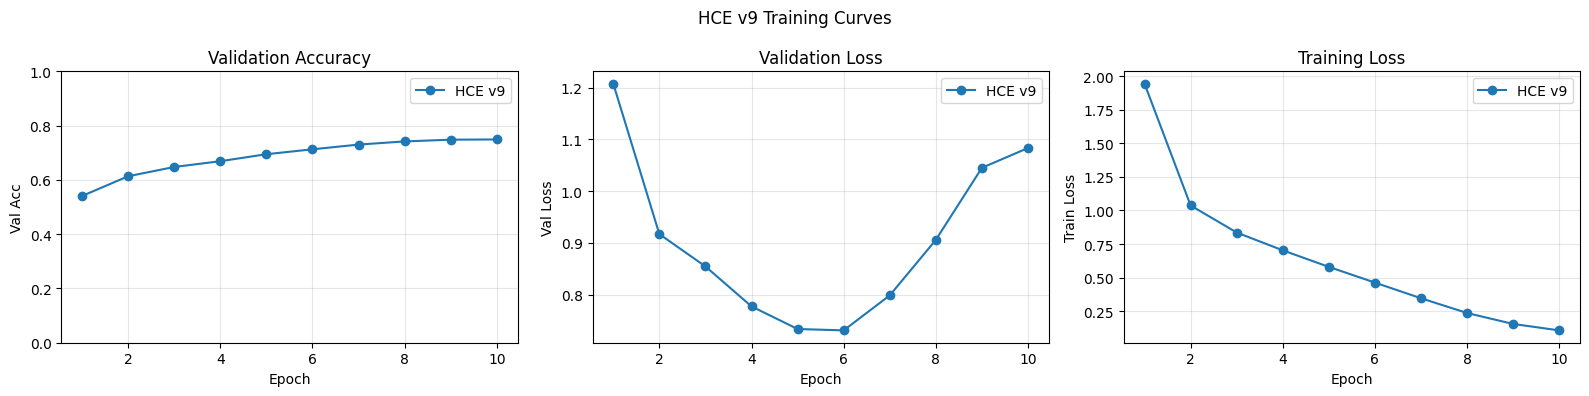

In [18]:
# v9 Stage 1: skip training curves when reusing v8 checkpoint (no history available)
if hce_history is None:
    print('  Skipping training curves — checkpoint loaded from v8 (no training history)')
else:
    epochs_ax = np.arange(1, N_EPOCHS + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(epochs_ax, hce_history['val_acc'], 'o-', label='HCE v9')
    axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Acc')
    axes[0].set_ylim(0, 1); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs_ax, hce_history['val_loss'], 'o-', label='HCE v9')
    axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(epochs_ax, hce_history['train_loss'], 'o-', label='HCE v9')
    axes[2].set_title('Training Loss'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train Loss')
    axes[2].legend(); axes[2].grid(alpha=0.3)
    plt.suptitle('HCE v9 Training Curves')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'hce_v9_training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 11. Per-Class Recall by Organ

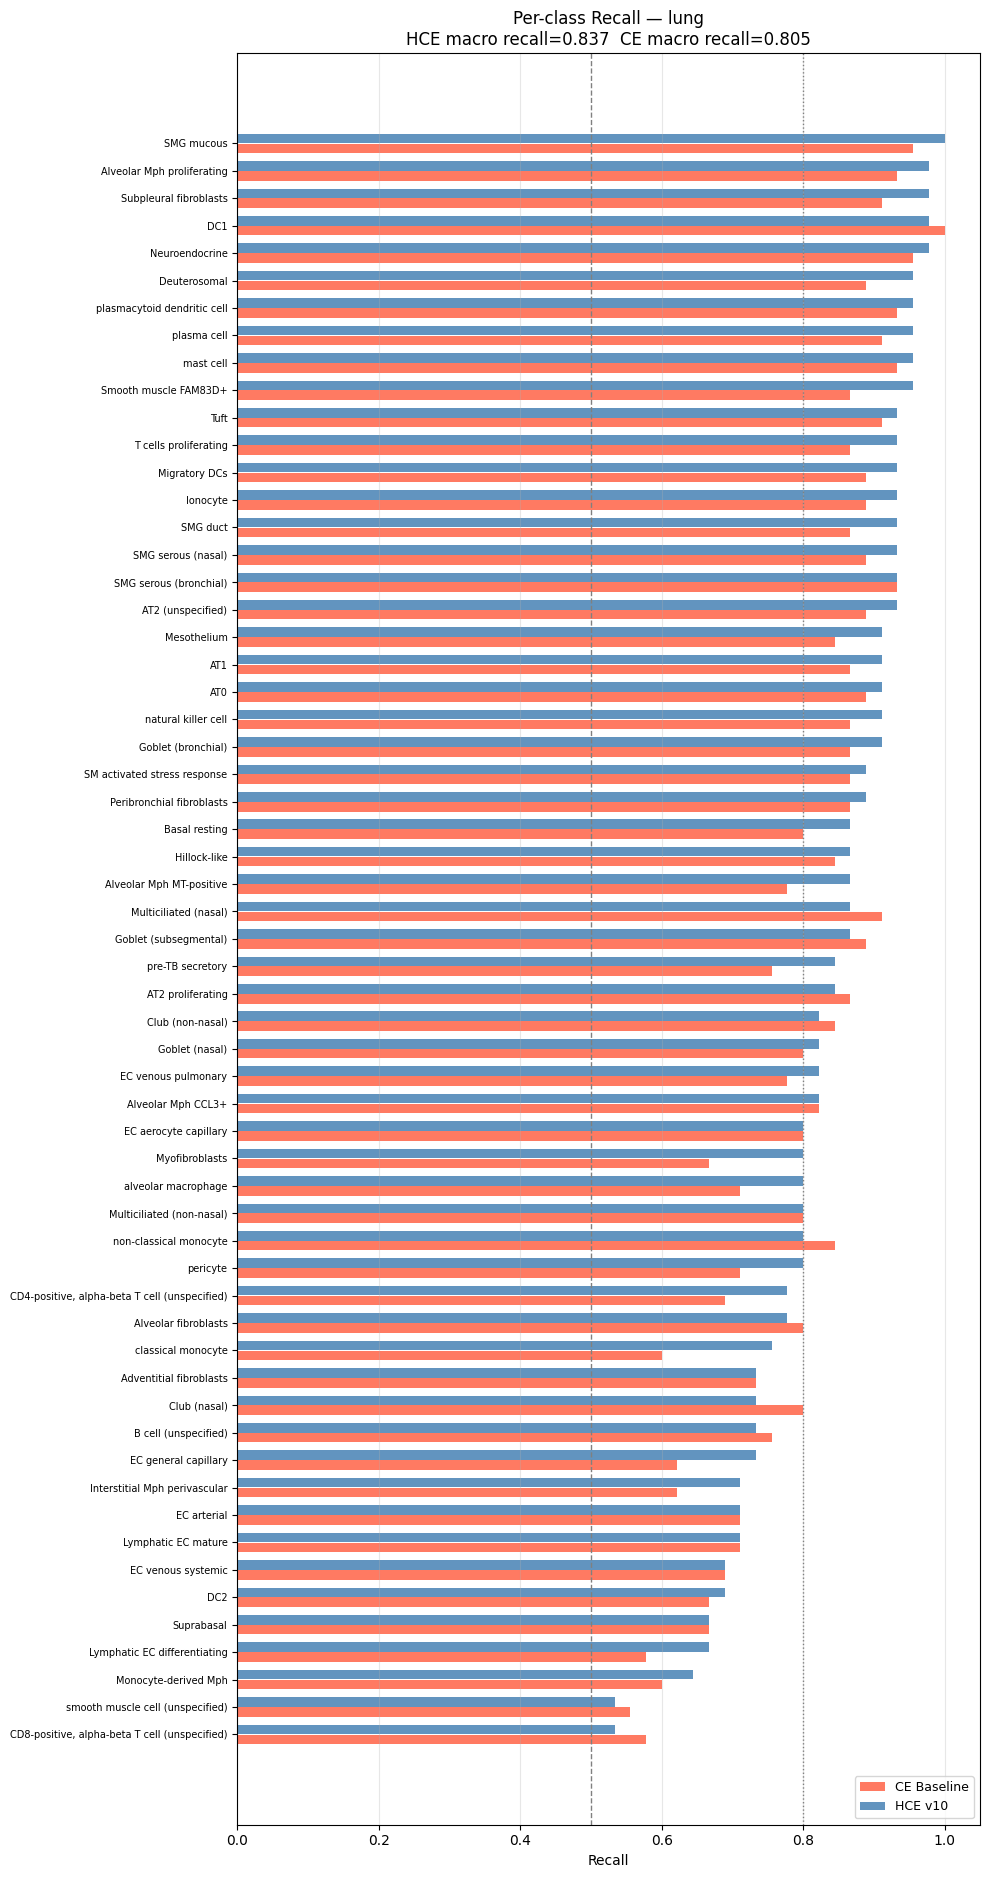

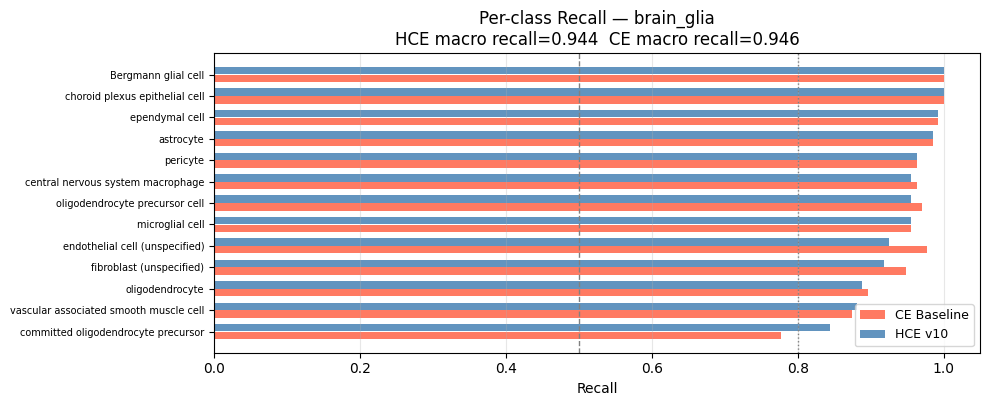

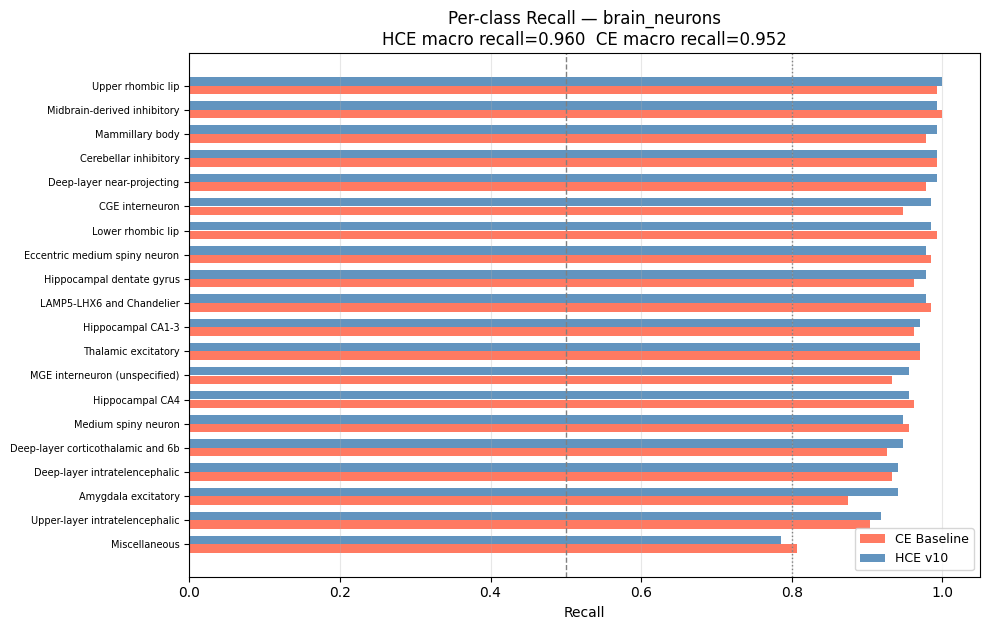

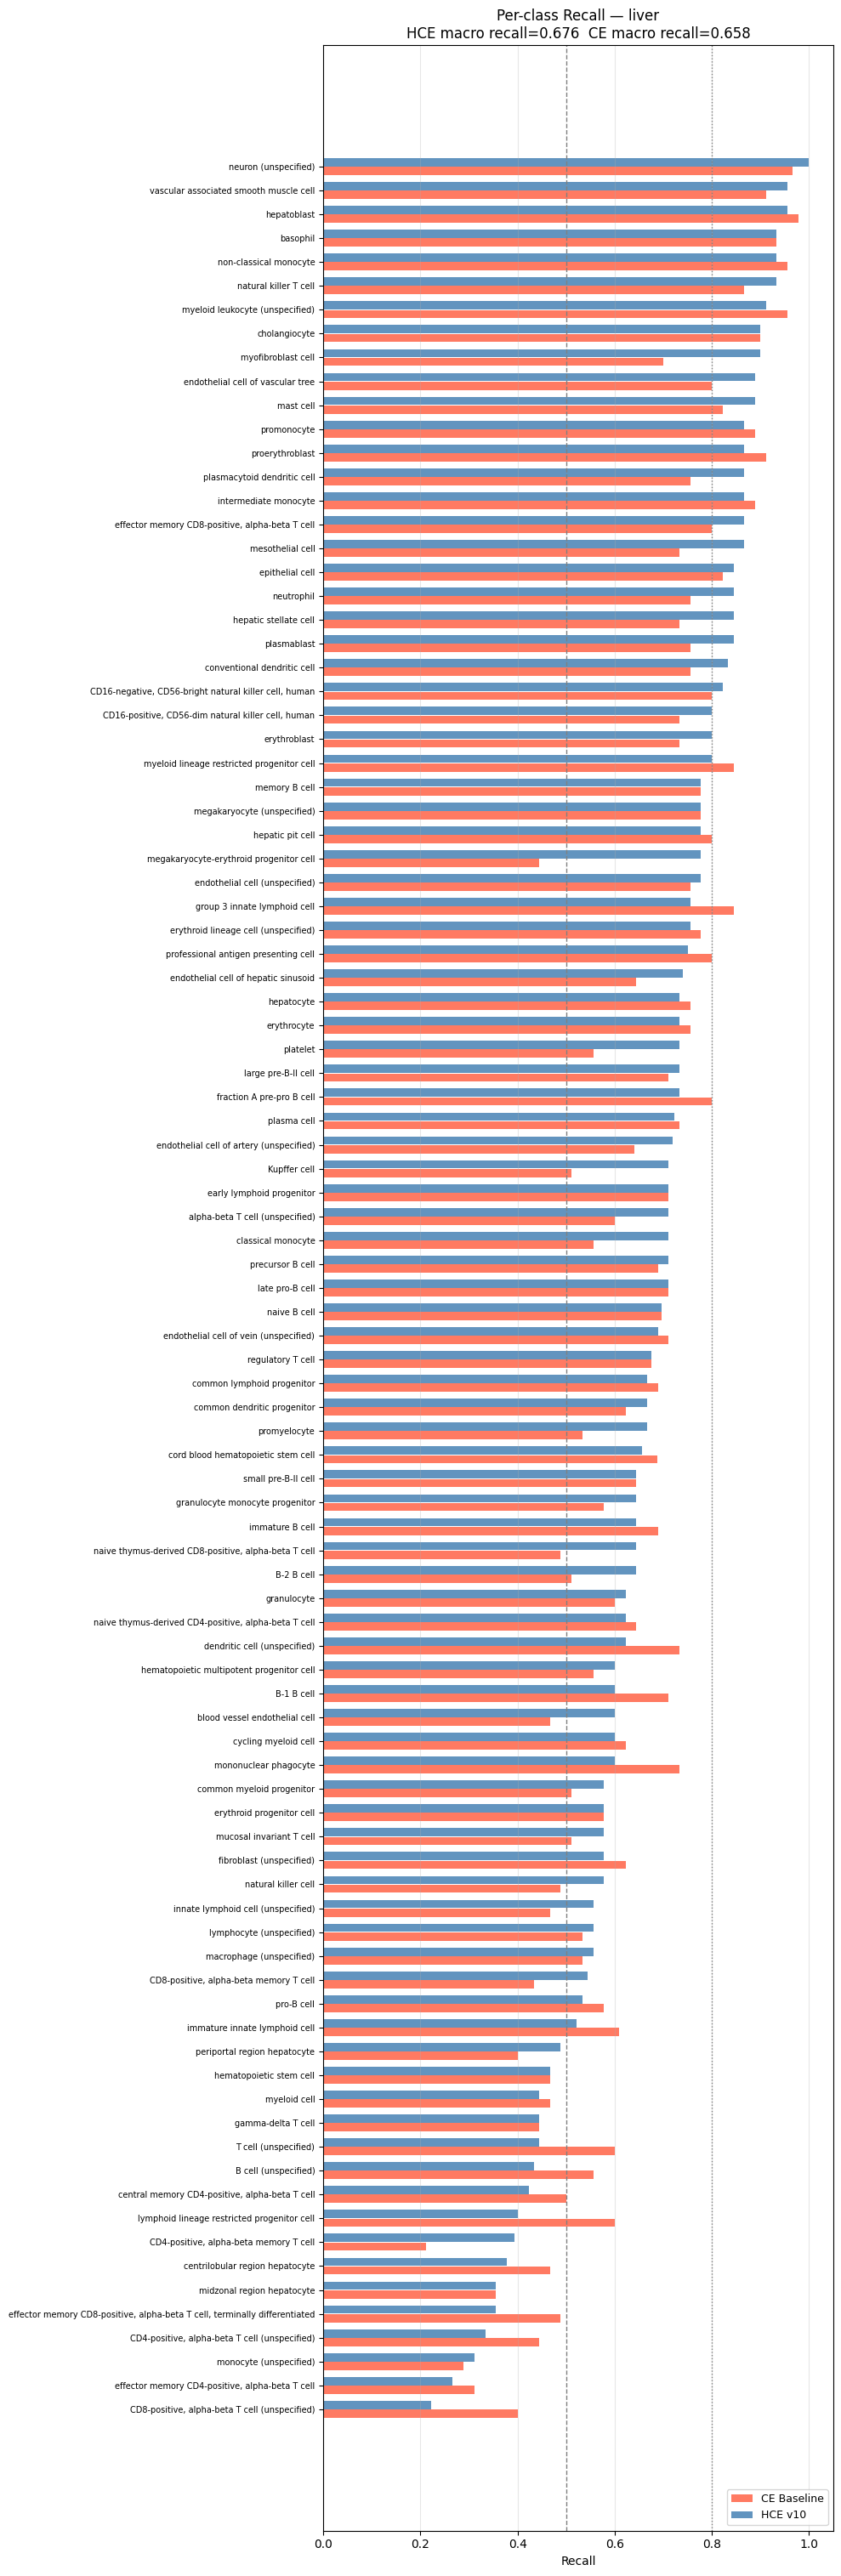

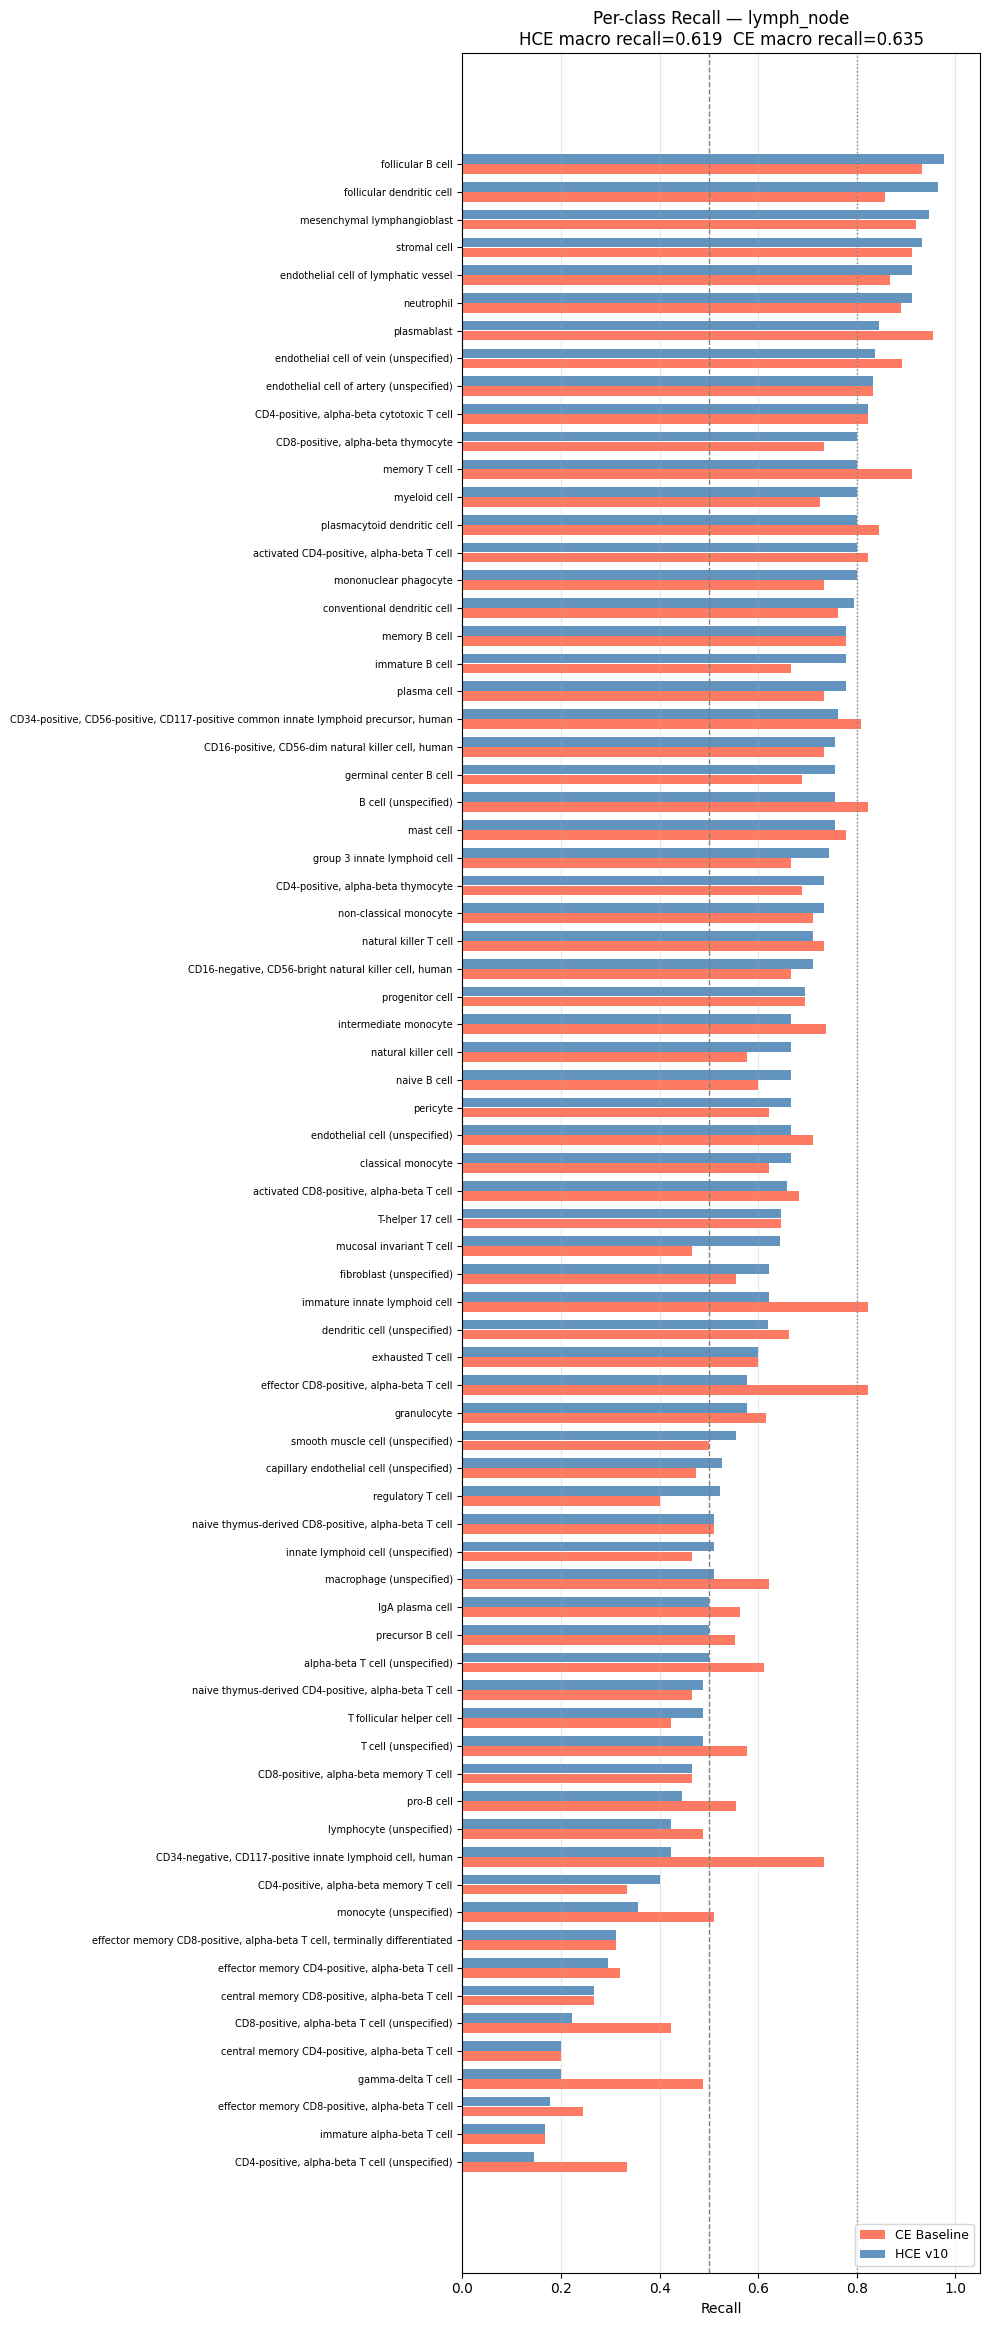

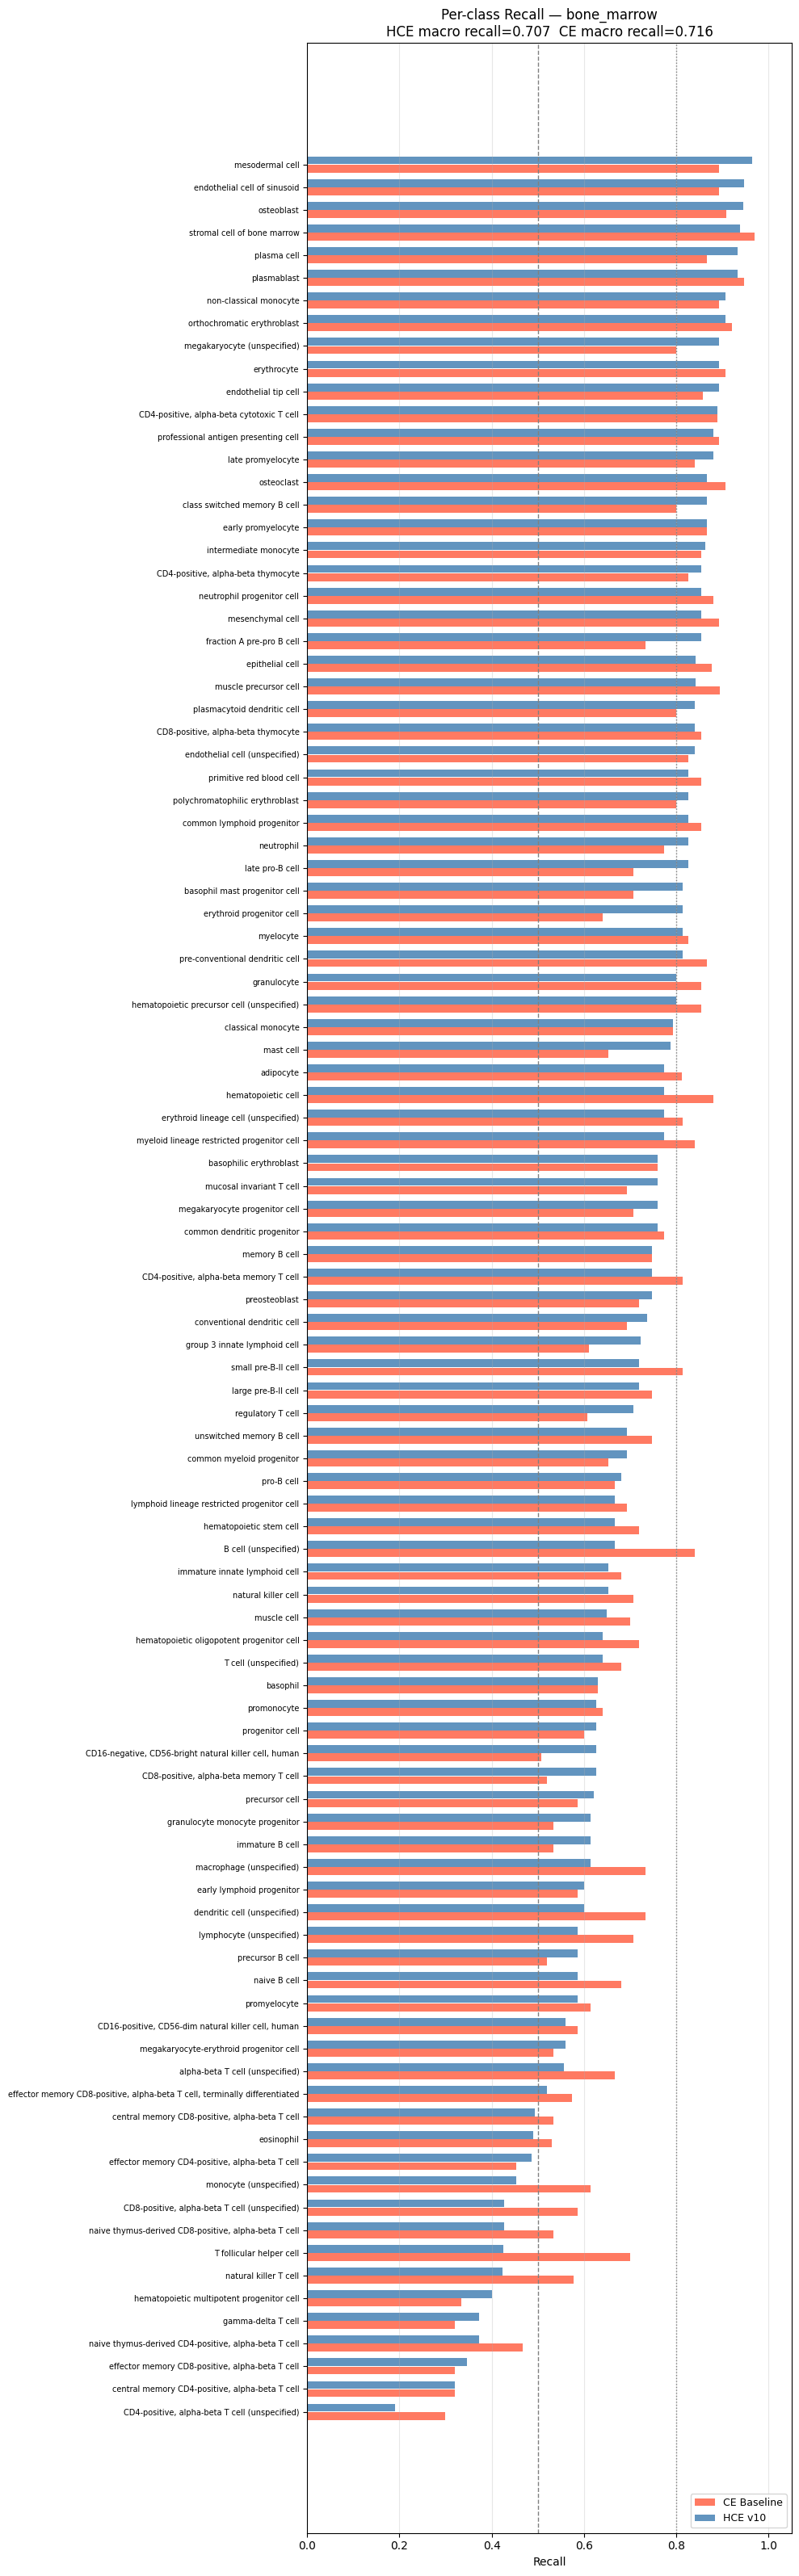

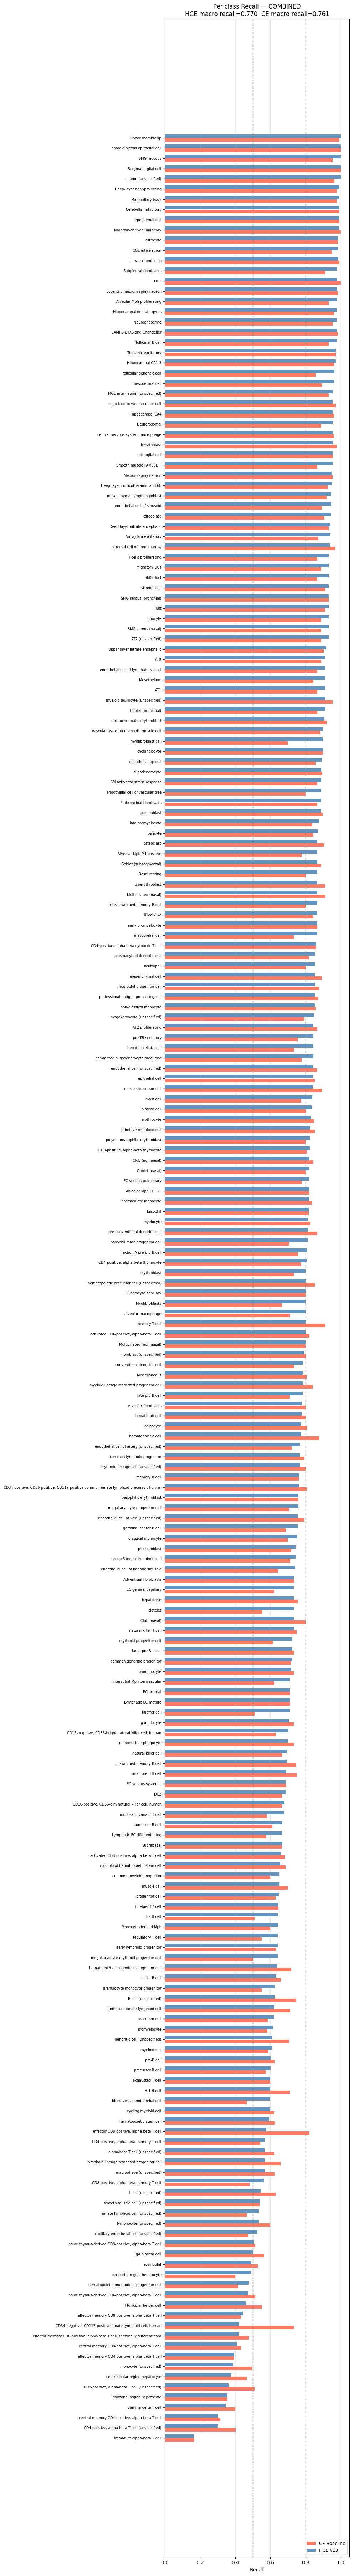

In [19]:
# v10: per-class recall comparison HCE vs CE (head-to-head bars per organ)
def plot_recall_comparison(organ_name, hce_metrics, ce_metrics):
    hce_pc = hce_metrics['per_class'].set_index('cell_type')['recall']
    ce_pc  = ce_metrics['per_class'].set_index('cell_type')['recall']
    all_ct = sorted(set(hce_pc.index) | set(ce_pc.index),
                    key=lambda ct: hce_pc.get(ct, 0))
    hce_vals = [hce_pc.get(ct, 0) for ct in all_ct]
    ce_vals  = [ce_pc.get(ct, 0)  for ct in all_ct]
    n = len(all_ct)
    fig, ax = plt.subplots(figsize=(10, max(4, n * 0.32)))
    y = np.arange(n)
    ax.barh(y - 0.18, ce_vals,  height=0.35, color='tomato',    label='CE Baseline', alpha=0.85)
    ax.barh(y + 0.18, hce_vals, height=0.35, color='steelblue', label='HCE v10',     alpha=0.85)
    ax.axvline(0.5, color='gray', ls='--', lw=1)
    ax.axvline(0.8, color='gray', ls=':',  lw=1)
    ax.set_yticks(y); ax.set_yticklabels(all_ct, fontsize=7)
    ax.set_xlim(0, 1.05); ax.set_xlabel('Recall')
    ax.set_title(f'Per-class Recall — {organ_name}\n'
                 f'HCE macro recall={hce_metrics["macro_recall"]:.3f}  '
                 f'CE macro recall={ce_metrics["macro_recall"]:.3f}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    safe = organ_name.replace(' ', '_').replace('(','').replace(')','')
    plt.savefig(os.path.join(OUT_DIR, f'recall_comparison_{safe}.png'), dpi=150, bbox_inches='tight')
    plt.show()

for cfg in ORGAN_CONFIGS:
    name = cfg['name']
    if name in results_hce and name in results_ce:
        plot_recall_comparison(name, results_hce[name], results_ce[name])
plot_recall_comparison('COMBINED', results_hce['COMBINED'], results_ce['COMBINED'])


## 12. Recall Distribution

  HCE — mean recall: 0.7703  |  median: 0.8000  |  0% classes: 0


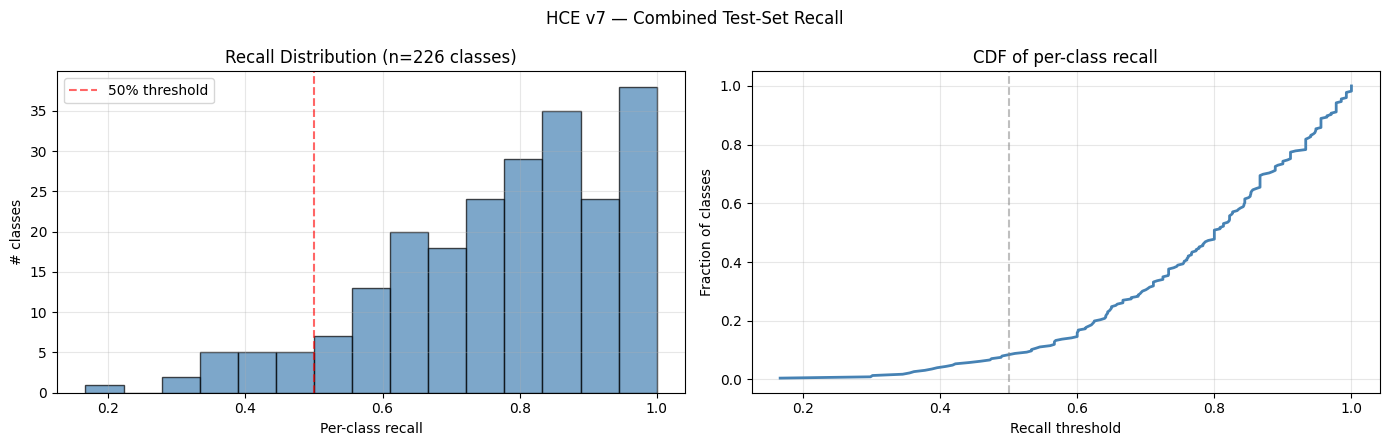

In [20]:
hce_recalls = results_hce['COMBINED']['per_class']['recall'].values
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(hce_recalls, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.6, label='50% threshold')
axes[0].set_title(f'Recall Distribution (n={len(hce_recalls)} classes)')
axes[0].set_xlabel('Per-class recall'); axes[0].set_ylabel('# classes')
axes[0].legend(); axes[0].grid(alpha=0.3)

sorted_r = np.sort(hce_recalls)
cdf      = np.arange(1, len(sorted_r) + 1) / len(sorted_r)
axes[1].plot(sorted_r, cdf, '-', linewidth=2, color='steelblue')
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('CDF of per-class recall'); axes[1].set_xlabel('Recall threshold'); axes[1].set_ylabel('Fraction of classes')
axes[1].grid(alpha=0.3)

print(f'  HCE — mean recall: {hce_recalls.mean():.4f}  |  median: {np.median(hce_recalls):.4f}  |  0% classes: {(hce_recalls == 0).sum()}')

plt.suptitle('HCE v7 — Combined Test-Set Recall')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hce_v7_recall_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Zero-Shot Inference *(6 lab datasets)*

In [21]:
class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.texts, self.tokenizer, self.max_length = texts, tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx] if self.texts[idx].strip() else '[PAD]',
            truncation=True, max_length=self.max_length,
            padding='max_length', return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0)}


# ── S1-A: mask "(unspecified)" leaves from leaf argmax ──────────────────────
specific_leaf_classes = [c for c in leaf_classes if not c.endswith(' (unspecified)')]
specific_leaf_indices = [class_to_idx[c] for c in specific_leaf_classes]
specific_leaf_indices_t = torch.tensor(specific_leaf_indices, device=device)
masked_count = len(leaf_indices) - len(specific_leaf_indices)
print(f'  S1-A: masked {masked_count} "(unspecified)" leaves  ({len(specific_leaf_indices)} specific leaves remain)')


# ── Ancestor reachability + node depths (for HCE roll-up) ───────────────────
ancestors_of_leaf = {}
for leaf_idx in leaf_indices:
    ancestors_of_leaf[leaf_idx] = [i for i in range(n_classes) if R_np[i, leaf_idx] > 0]

def _compute_depths():
    depths = {name: None for name in class_names}
    def depth_of(name, seen=None):
        seen = seen or set()
        if name in seen: return 0
        if depths[name] is not None: return depths[name]
        parent = combined_ontology.get(name)
        if parent is None or parent not in depths:
            depths[name] = 0
        else:
            depths[name] = 1 + depth_of(parent, seen | {name})
        return depths[name]
    for nm in class_names: depth_of(nm)
    return depths
node_depth = _compute_depths()
depth_arr  = np.array([node_depth[nm] for nm in class_names], dtype=int)


# ── S1-C: adaptive roll-up (HCE only) ───────────────────────────────────────
def rollup_pred(leaf_probs_row, tau_leaf=TAU_LEAF):
    leaf_max_idx = int(np.argmax(leaf_probs_row))
    leaf_max_p   = float(leaf_probs_row[leaf_max_idx])
    if leaf_max_p >= tau_leaf:
        return leaf_indices[leaf_max_idx], leaf_max_p, False
    s = np.zeros(n_classes, dtype=float)
    for k, leaf_idx in enumerate(leaf_indices):
        p = leaf_probs_row[k]
        if p <= 0: continue
        for anc_idx in ancestors_of_leaf[leaf_idx]:
            s[anc_idx] += p
    tau_adaptive = max(0.4, min(1.0, 2.5 * leaf_max_p))
    candidate_mask = s >= tau_adaptive
    if not candidate_mask.any():
        return leaf_indices[leaf_max_idx], leaf_max_p, False
    cand_idx = np.where(candidate_mask)[0]
    best = max(cand_idx, key=lambda i: (depth_arr[i], s[i]))
    return int(best), float(s[best]), True


def run_inference_hce(model, texts, temperature=1.0):
    """HCE: S1-A specific-leaf argmax + S1-C adaptive rollup on full leaf set."""
    inf_loader = DataLoader(
        InferenceDataset(texts, tokenizer, MAX_SEQ_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=2, pin_memory=True
    )
    leaf_preds, leaf_confs = [], []
    lin_preds, lin_confs, lin_rolled = [], [], []
    model.eval()
    with torch.no_grad():
        for batch in tqdm(inf_loader, desc='    [HCE] infer', leave=False):
            logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            spec = torch.softmax(logits[:, specific_leaf_indices_t] / temperature, dim=1)
            pp = spec.argmax(dim=1)
            leaf_preds.extend(specific_leaf_indices_t[pp].cpu().numpy())
            leaf_confs.extend(spec.max(dim=1).values.cpu().numpy())
            full = torch.softmax(logits[:, leaf_indices_t] / temperature, dim=1).cpu().numpy()
            for row in full:
                idx, p, rolled = rollup_pred(row)
                lin_preds.append(idx); lin_confs.append(p); lin_rolled.append(rolled)
    return ([class_names[i] for i in leaf_preds], np.array(leaf_confs),
            [class_names[i] for i in lin_preds],  np.array(lin_confs), np.array(lin_rolled))


def run_inference_ce(model, texts, temperature=1.0):
    """CE: S1-A specific-leaf argmax, no rollup (CE has no hierarchy)."""
    inf_loader = DataLoader(
        InferenceDataset(texts, tokenizer, MAX_SEQ_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=2, pin_memory=True
    )
    leaf_preds, leaf_confs = [], []
    model.eval()
    with torch.no_grad():
        for batch in tqdm(inf_loader, desc='    [CE]  infer', leave=False):
            logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            spec = torch.softmax(logits[:, specific_leaf_indices_t] / temperature, dim=1)
            pp = spec.argmax(dim=1)
            leaf_preds.extend(specific_leaf_indices_t[pp].cpu().numpy())
            leaf_confs.extend(spec.max(dim=1).values.cpu().numpy())
    return ([class_names[i] for i in leaf_preds], np.array(leaf_confs))


# ── S1-B FIXED: per-row sparse-safe total counts diagnostic ─────────────────
import random
random.seed(SEED)
print('\n  S1-B: protocol diagnostic for Brain_normal / All_cells (glioma):')
for lab_cfg in LAB_CONFIGS:
    if lab_cfg['name'] not in ('Brain_normal', 'All_cells (glioma)'): continue
    try:
        ad = sc.read_h5ad(lab_cfg['path'], backed='r')
        cols = list(ad.obs.columns)
        sample_idx = sorted(random.sample(range(ad.n_obs), min(200, ad.n_obs)))
        sample_totals = []
        for ix in sample_idx:
            row = ad.X[ix]
            sample_totals.append(float(row.sum() if sp.issparse(row) else np.asarray(row).sum()))
        median_total = float(np.median(sample_totals))
        guess = 'snRNA-seq' if median_total < 8000 else 'scRNA-seq'
        print(f'    [{lab_cfg["name"]}]  obs cols (first 10): {cols[:10]}')
        print(f'      median total counts on 200-cell sample = {median_total:.0f}  →  likely {guess}')
        print(f'      current snrna_seq flag = {lab_cfg["snrna_seq"]}')
        if (guess == "snRNA-seq") != lab_cfg["snrna_seq"]:
            print(f'      ⚠ MISMATCH — consider flipping snrna_seq for {lab_cfg["name"]}')
    except Exception as e:
        print(f'    [{lab_cfg["name"]}] diagnostic failed: {e}')


# ── Zero-shot inference loop — run BOTH models on each lab dataset ──────────
lab_results_hce = {}
lab_results_ce  = {}

for lab_cfg in LAB_CONFIGS:
    lab_name  = lab_cfg['name']
    label_col = lab_cfg['label_col']
    sn_flag   = lab_cfg.get('snrna_seq', False)
    print(f'\n  --- {lab_name} ---  (snrna_seq={sn_flag})')

    adata_lab = sc.read_h5ad(lab_cfg['path'])
    lab_gene_sym = get_gene_symbols(adata_lab)
    lab_gene_keep = keep_gene_mask(lab_gene_sym)
    lab_gene_lengths = get_gene_lengths(adata_lab, lab_gene_sym) if sn_flag else None
    true_labels = adata_lab.obs[label_col].astype(str).values
    X_lab = adata_lab.X
    texts = [cell_to_text_dense(X_lab[i], lab_gene_sym, TOP_K_GENES,
                                 gene_keep=lab_gene_keep,
                                 gene_lengths=lab_gene_lengths,
                                 length_normalize=sn_flag)
             for i in tqdm(range(adata_lab.n_obs), desc='    text', leave=False)]

    h_leaf, h_conf, h_lin, h_lconf, h_rolled = run_inference_hce(hce_model, texts, TEMPERATURE_HCE)
    c_leaf, c_conf = run_inference_ce(ce_model, texts, TEMPERATURE_CE)

    lab_results_hce[lab_name] = pd.DataFrame({
        'true_label': true_labels,
        'pred_leaf': h_leaf, 'conf_leaf': h_conf,
        'pred_lineage': h_lin, 'conf_lineage': h_lconf, 'rolled_up': h_rolled,
    })
    lab_results_ce[lab_name] = pd.DataFrame({
        'true_label': true_labels,
        'pred_leaf': c_leaf, 'conf_leaf': c_conf,
    })

    print(f'  HCE roll-up rate: {h_rolled.mean()*100:.1f}%')
    print(f'  {"True label":<40} {"HCE leaf":>40} {"HCE lineage":>40} {"CE leaf":>40}')
    print('  ' + '-' * 162)
    df_h = lab_results_hce[lab_name]; df_c = lab_results_ce[lab_name]
    for true_lbl in sorted(np.unique(true_labels)):
        sub_h = df_h[df_h['true_label']==true_lbl]
        sub_c = df_c[df_c['true_label']==true_lbl]
        ht = sub_h['pred_leaf'].value_counts()
        nt = sub_h['pred_lineage'].value_counts()
        ct = sub_c['pred_leaf'].value_counts()
        def _top(vc):
            return f'{vc.index[0]}  ({vc.iloc[0]/vc.sum()*100:.0f}%)' if len(vc) else 'N/A'
        print(f'  {true_lbl:<40} {_top(ht):>40} {_top(nt):>40} {_top(ct):>40}')

print('\n[OK] Zero-shot inference complete for HCE + CE')


  S1-A: masked 23 "(unspecified)" leaves  (203 specific leaves remain)

  S1-B: protocol diagnostic for Brain_normal / All_cells (glioma):
    [All_cells (glioma)]  obs cols (first 10): ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'predicted.high_hierarchy', 'patient', 'remarks', 'ident']
      median total counts on 200-cell sample = 3385  →  likely snRNA-seq
      current snrna_seq flag = False
      ⚠ MISMATCH — consider flipping snrna_seq for All_cells (glioma)
    [Brain_normal]  obs cols (first 10): ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_name', 'patient_id', 'mount_batch', 'organ_site', 'percent.mt', 'cell_type', 'cell_class']
      median total counts on 200-cell sample = 2580  →  likely snRNA-seq
      current snrna_seq flag = False
      ⚠ MISMATCH — consider flipping snrna_seq for Brain_normal

  --- All_cells (glioma) ---  (snrna_seq=False)


  HCE roll-up rate: 10.8%
  True label                                                               HCE leaf                              HCE lineage                                  CE leaf
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------
  AC-like                                  committed oligodendrocyte precursor  (51%) committed oligodendrocyte precursor  (50%) committed oligodendrocyte precursor  (44%)
  Astrocyte                                committed oligodendrocyte precursor  (31%) committed oligodendrocyte precursor  (30%)                         astrocyte  (62%)
  CD4/CD8                                                natural killer cell  (52%) CD8-positive, alpha-beta T cell (unspecified)  (32%)                 regulatory T cell  (26%)
  DC                                       committed oligodendrocyte precursor  (11%) committed oligodendrocyte precursor  

  HCE roll-up rate: 9.4%
  True label                                                               HCE leaf                              HCE lineage                                  CE leaf
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------
  GABAergic_interneuron                                             pericyte  (15%)            monocyte (unspecified)  (12%)                     Miscellaneous  (15%)
  GABAergic_interneuron_SST                        follicular dendritic cell  (15%)          fibroblast (unspecified)  (13%)                     Miscellaneous  (15%)
  arterial_endothelial_cell                             EC general capillary  (36%)              EC general capillary  (29%)              EC general capillary  (19%)
  astrocyte_fibrous_like                    endothelial cell of vascular tree  (8%)    endothelial cell (unspecified)  (14%)              Alveolar

  HCE roll-up rate: 2.4%
  True label                                                               HCE leaf                              HCE lineage                                  CE leaf
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------
  arterial_endothelial_cell                             EC general capillary  (36%)              EC general capillary  (28%)              EC general capillary  (26%)
  cholangiocyte                                                cholangiocyte  (74%)                     cholangiocyte  (68%)                     cholangiocyte  (45%)
  endothelial_cell_proliferating           endothelial cell of hepatic sinusoid  (26%)    endothelial cell (unspecified)  (19%)              EC general capillary  (26%)
  hepatic_stellate_cell_ACTA2_high                                  pericyte  (24%)                          pericyte  (15%)                   

  HCE roll-up rate: 1.9%
  True label                                                               HCE leaf                              HCE lineage                                  CE leaf
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------
  LN_fibroblast_collagen_high                      Peribronchial fibroblasts  (68%)         Peribronchial fibroblasts  (65%)         Peribronchial fibroblasts  (76%)
  LN_stroma_cell                                   Peribronchial fibroblasts  (71%)         Peribronchial fibroblasts  (68%)         Peribronchial fibroblasts  (70%)
  LN_stroma_cell_CHI3L1                            Peribronchial fibroblasts  (59%)         Peribronchial fibroblasts  (57%)         Peribronchial fibroblasts  (59%)
  adipocyte                                                     stromal cell  (43%)                      stromal cell  (39%)                      

  HCE roll-up rate: 27.4%
  True label                                                               HCE leaf                              HCE lineage                                  CE leaf
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------
  B_cell                                                         plasma cell  (21%)              B cell (unspecified)  (45%)                       plasma cell  (33%)
  B_cell_naive                                                   plasma cell  (28%)              B cell (unspecified)  (38%)                       plasma cell  (33%)
  CD4_T_cell_activated                                   natural killer cell  (18%)                         leukocyte  (19%)       plasmacytoid dendritic cell  (12%)
  CD4_T_cell_naive_or_memory                             natural killer cell  (15%)                         leukocyte  (17%)       plasmacytoid d

  HCE roll-up rate: 20.6%
  True label                                                               HCE leaf                              HCE lineage                                  CE leaf
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------
  alveolar_macrophage                                     Alveolar Mph CCL3+  (17%)                Alveolar Mph CCL3+  (15%)               alveolar macrophage  (27%)
  cDC1                                           conventional dendritic cell  (22%)          macrophage (unspecified)  (18%)                               DC2  (39%)
  macrophage_APOE_CHIT                         Interstitial Mph perivascular  (18%)          macrophage (unspecified)  (36%)     Interstitial Mph perivascular  (15%)
  macrophage_C3                                Interstitial Mph perivascular  (25%)     Interstitial Mph perivascular  (18%)     Interstitial Mph

## 14. Deeper Biological-Accuracy Analysis

Top-5 predictions per true class, lineage-match rate, and ancestor recall on the in-distribution test set.

In [22]:
# Coarse lineage assignment for any free-form label
LINEAGE_RULES = [
    ('Myeloid',                 ['macroph','monocyte','microglia','dendritic',' dc ','tam-','tam_','tam ',
                                 'kupffer','neutrophil','mast cell','eosinophil','basophil','myeloid',
                                 'granulocyte','histiocyt','langerhans',
                                 ' mph',' mph ','interstitial mph','alveolar mph','monocyte-derived','myelocyte','promyelocyte','mononuclear phagocyte']),
    ('Lymphoid',                ['t cell','t_cell','cd4','cd8','b cell','b_cell','nk cell','natural killer',
                                 'plasma cell','plasmablast','lymphocyte','lymphoid','innate lymphoid',
                                 ' ilc','follicular helper','regulatory t','gamma-delta','germinal center']),
    ('Erythroid/Megakaryocyte', ['erythro','reticulocyt','megakaryo','platelet']),
    ('Hematopoietic Progenitor',['hematopoietic','hsc',' progenitor','precursor cell']),
    ('Endothelial',             ['endothel','high endothelial venule','ec arterial','ec venous',
                                 'ec general','lymphatic ec','arterial_endothel','venous_endothel',
                                 'capillary_endothel','ec aerocyte','ec capillary','endothelial tip']),
    ('Mesenchymal/Stromal',     ['fibroblast','stellate','pericyte','smooth muscle','smooth_muscle',
                                 'adipocyte','mesenchym','perivascular','meningeal','stroma',
                                 'myofibro','tenocyte','chondrocyte']),
    ('Epithelial',              ['hepatocyt','hepatoblast','cholangio','epithel','enterocyt',
                                 'alveolar type','hepatic cell','goblet','keratino','urothel','tuft']),
    ('Glial',                   ['astrocyt','oligodendro','opc','glia','bergmann','ependymal',
                                 'choroid plexus']),
    ('Neuronal',                ['neuron','interneuron','intratelencephal','hippocampal','thalamic',
                                 'amygdala','rhombic','mammillary','medium spiny',' npc','purkinje',
                                 'granule cell','msn','gabaergic']),
    ('Tumor (glioma-like)',     ['ac-like','mes-like','npc-like','opc-like']),
]
def assign_lineage(label):
    if label is None or (isinstance(label, float) and pd.isna(label)): return 'Other'
    s = ' ' + str(label).lower().strip() + ' '
    for lineage, kws in LINEAGE_RULES:
        for kw in kws:
            if kw in s: return lineage
    return 'Other'

# (1) Top-5 predictions per true class
print('=' * 100)
print('  (1) TOP-5 PREDICTIONS PER TRUE CLASS (zero-shot)')
print('=' * 100)
for lab_name in lab_results_hce.keys():
    print(f'\n--- {lab_name} ---')
    df = lab_results_hce[lab_name]
    for true_lbl in sorted(df['true_label'].unique()):
        n = int((df['true_label'] == true_lbl).sum())
        top = df[df['true_label']==true_lbl]['pred_leaf'].value_counts(normalize=True).head(5)
        print(f'\n  {true_lbl}  (n={n})')
        print(f'    HCE : ' + '  |  '.join([f'{p}: {v*100:.0f}%' for p, v in top.items()]))

# (2) Lineage-match rate per dataset
print('\n' + '=' * 100)
print('  (2) LINEAGE-MATCH RATE')
print('=' * 100)
print(f'\n  {"Dataset":<26}{"HCE":>10}')
print('  ' + '-' * 36)
for lab_name in lab_results_hce.keys():
    df = lab_results_hce[lab_name]
    rate = (df['pred_leaf'].map(assign_lineage) == df['true_label'].map(assign_lineage)).mean()
    print(f'  {lab_name:<26}{rate*100:>9.1f}%')

# Combined pooled lineage match
combined = pd.concat(list(lab_results_hce.values()), ignore_index=True)
pooled   = (combined['pred_leaf'].map(assign_lineage) == combined['true_label'].map(assign_lineage)).mean()
print(f'\n  POOLED across {len(lab_results_hce)} datasets : {pooled*100:.1f}%')

# (3) Ancestor recall @ k on in-distribution test set
def ancestor_set(node, ontology, max_depth=30):
    out, cur, depth = set(), ontology.get(node), 0
    while cur is not None and depth < max_depth and cur not in out:
        out.add(cur); cur = ontology.get(cur); depth += 1
    return out

def lca_hops(true_name, pred_name, ontology, max_k=30):
    if true_name == pred_name: return 0
    true_or_anc = {true_name} | ancestor_set(true_name, ontology, max_k)
    cur, k = pred_name, 0
    while cur is not None and k < max_k:
        if cur in true_or_anc: return k
        cur = ontology.get(cur); k += 1
    return None

def ancestor_recall_table(preds, trues):
    cache, depths = {}, []
    for t, p in zip(trues, preds):
        key = (int(t), int(p))
        if key not in cache:
            cache[key] = lca_hops(class_names[t], class_names[p], combined_ontology)
        depths.append(cache[key])
    arr = np.array([d if d is not None else 999 for d in depths])
    return {
        'leaf-exact (k=0)':  float((arr == 0).mean()),
        'within k<=1':       float((arr <= 1).mean()),
        'within k<=2':       float((arr <= 2).mean()),
        'within k<=3':       float((arr <= 3).mean()),
        'any shared anc':    float((arr <= 30).mean()),
    }

print('\n' + '=' * 100)
print('  (3) ANCESTOR RECALL @ k  (in-distribution test set)')
print('=' * 100)
tbl = ancestor_recall_table(hce_preds, hce_trues)
print(f'\n  {"Metric":<22}{"HCE":>10}')
print('  ' + '-' * 32)
for k, v in tbl.items():
    print(f'  {k:<22}{v*100:>9.2f}%')

print('\n  Per-organ ancestor-recall @ k<=2:')
print(f'  {"Organ":<20}{"HCE":>10}')
print('  ' + '-' * 30)
test_organ_np = np.asarray(test_organ)
for cfg in ORGAN_CONFIGS:
    mask = (test_organ_np == cfg['id'])
    if mask.sum() == 0: continue
    sub = ancestor_recall_table(hce_preds[mask], hce_trues[mask])
    print(f'  {cfg["name"]:<20}{sub["within k<=2"]*100:>9.2f}%')

print('\n[OK] Deep biological-accuracy analysis complete')

  (1) TOP-5 PREDICTIONS PER TRUE CLASS (zero-shot)

--- All_cells (glioma) ---

  AC-like  (n=200)
    HCE : committed oligodendrocyte precursor: 51%  |  oligodendrocyte precursor cell: 20%  |  astrocyte: 6%  |  Deep-layer corticothalamic and 6b: 3%  |  Bergmann glial cell: 2%

  Astrocyte  (n=200)
    HCE : committed oligodendrocyte precursor: 31%  |  astrocyte: 30%  |  CGE interneuron: 6%  |  ependymal cell: 4%  |  oligodendrocyte precursor cell: 4%

  CD4/CD8  (n=200)
    HCE : natural killer cell: 52%  |  regulatory T cell: 16%  |  plasmacytoid dendritic cell: 8%  |  T follicular helper cell: 6%  |  natural killer T cell: 4%

  DC  (n=9)
    HCE : committed oligodendrocyte precursor: 11%  |  oligodendrocyte precursor cell: 11%  |  natural killer cell: 11%  |  plasmacytoid dendritic cell: 11%  |  T follicular helper cell: 11%

  Endothelial  (n=200)
    HCE : blood vessel endothelial cell: 21%  |  EC venous systemic: 13%  |  EC general capillary: 12%  |  pericyte: 11%  |  Lymphatic 

## 15. Confusion Matrix Visualizations

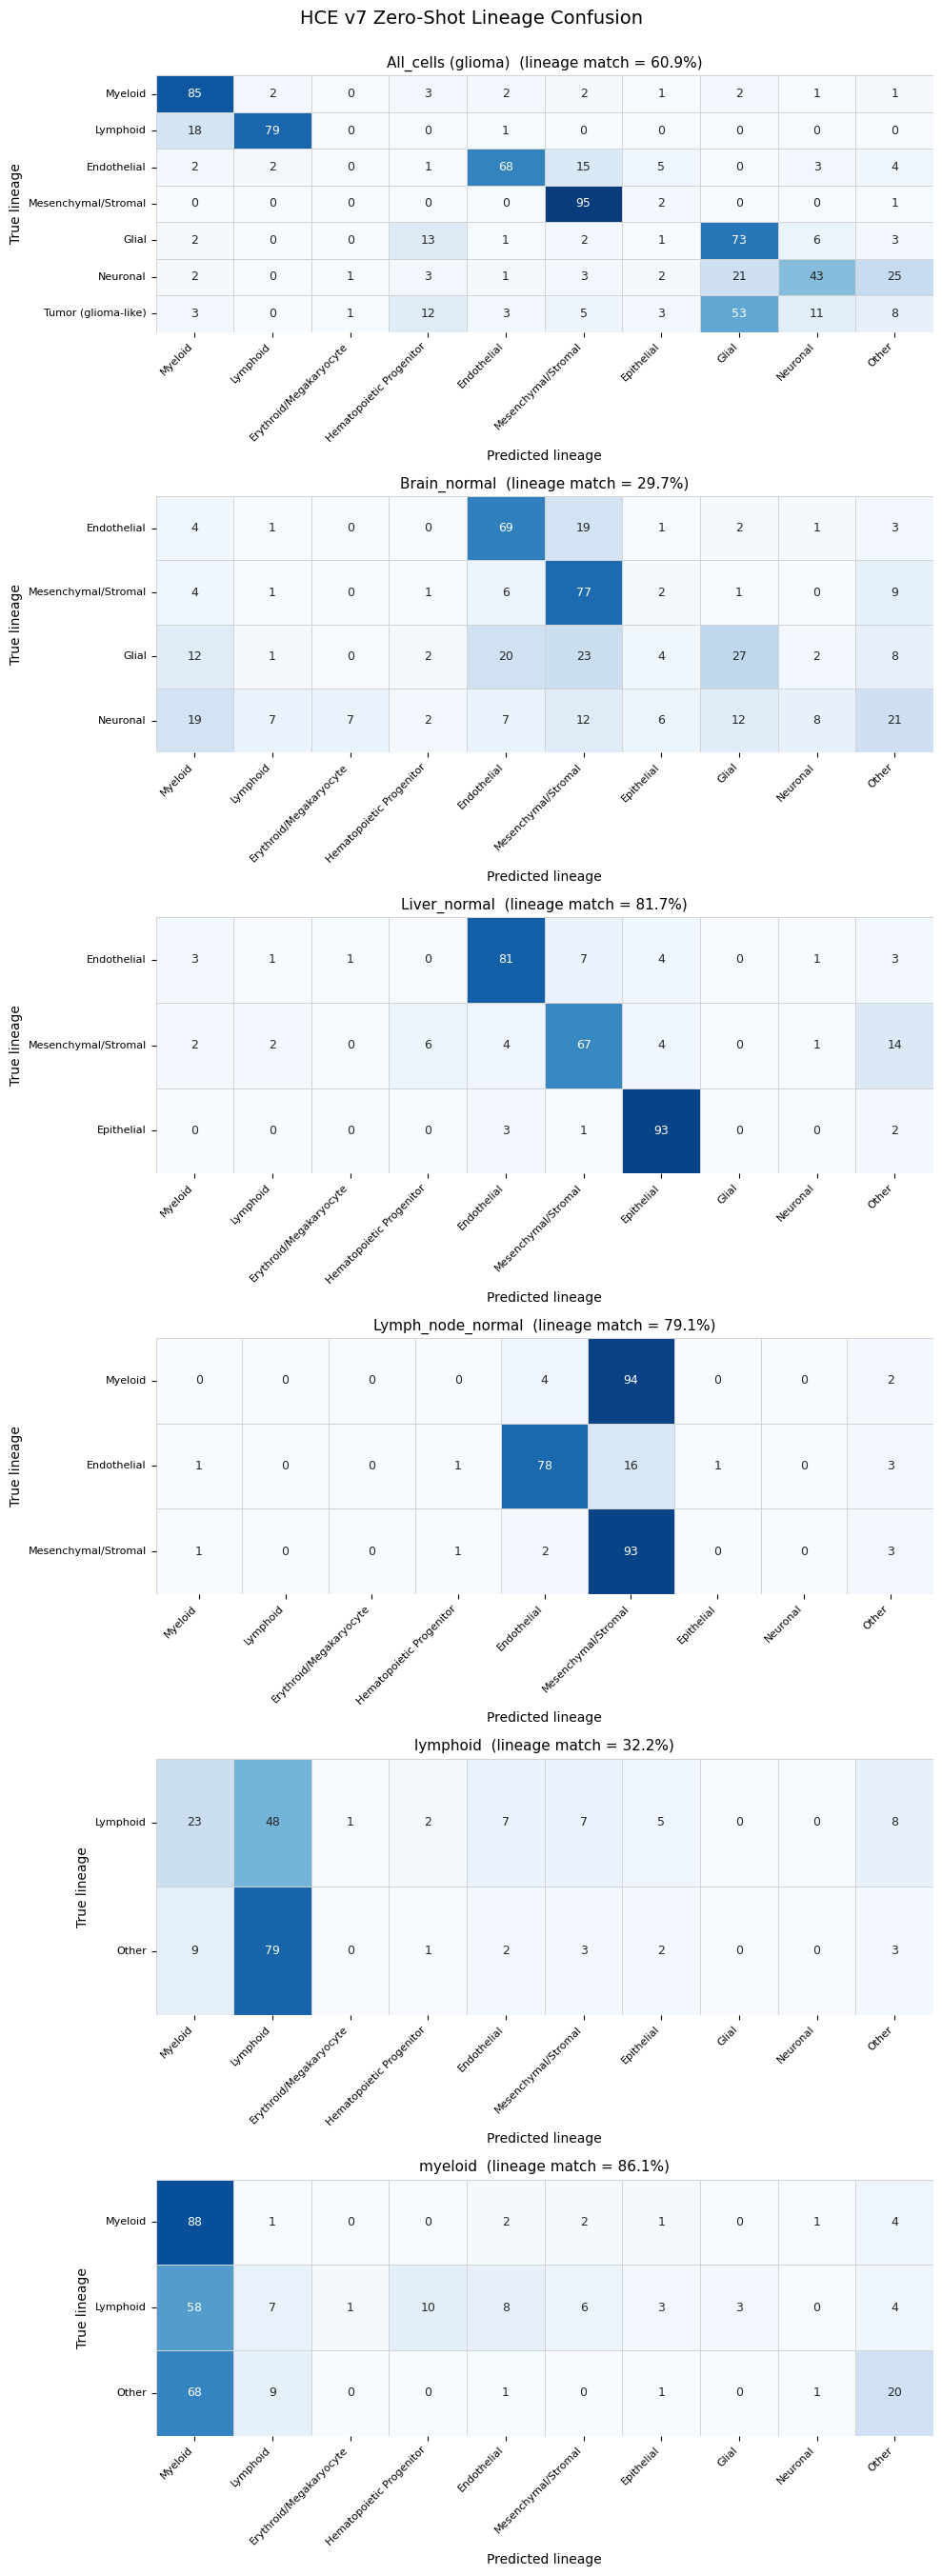

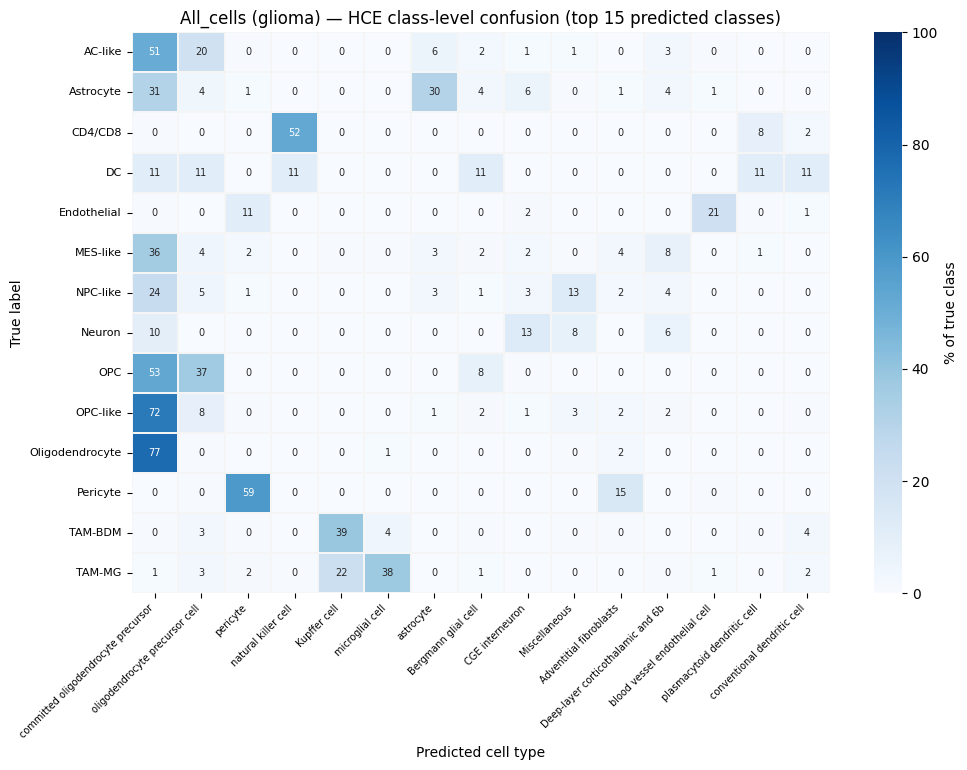

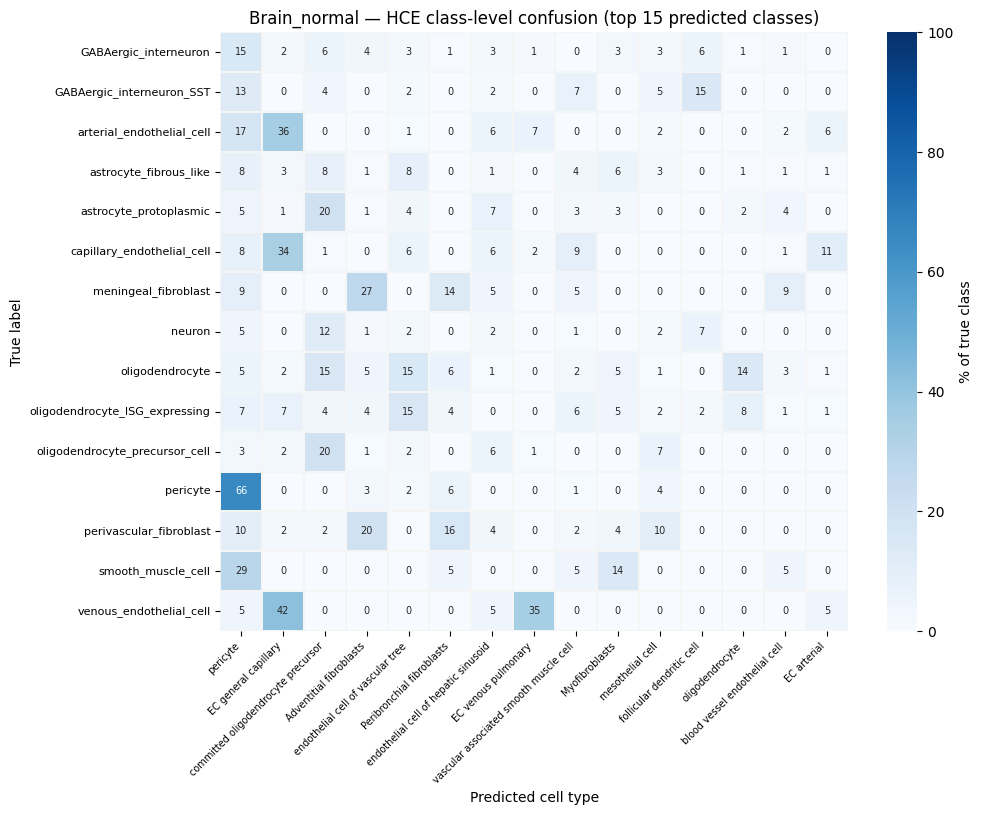

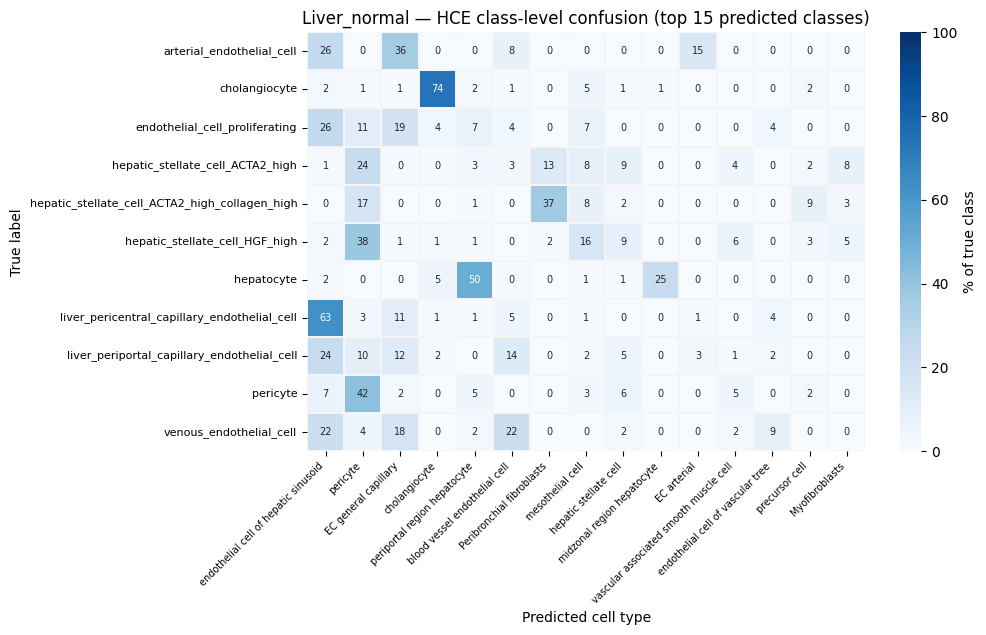

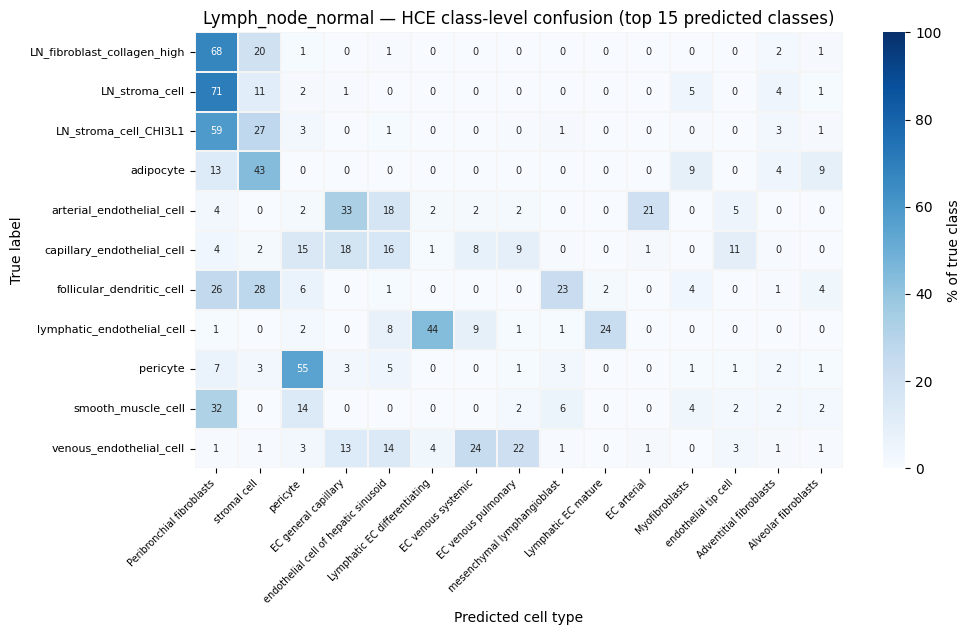

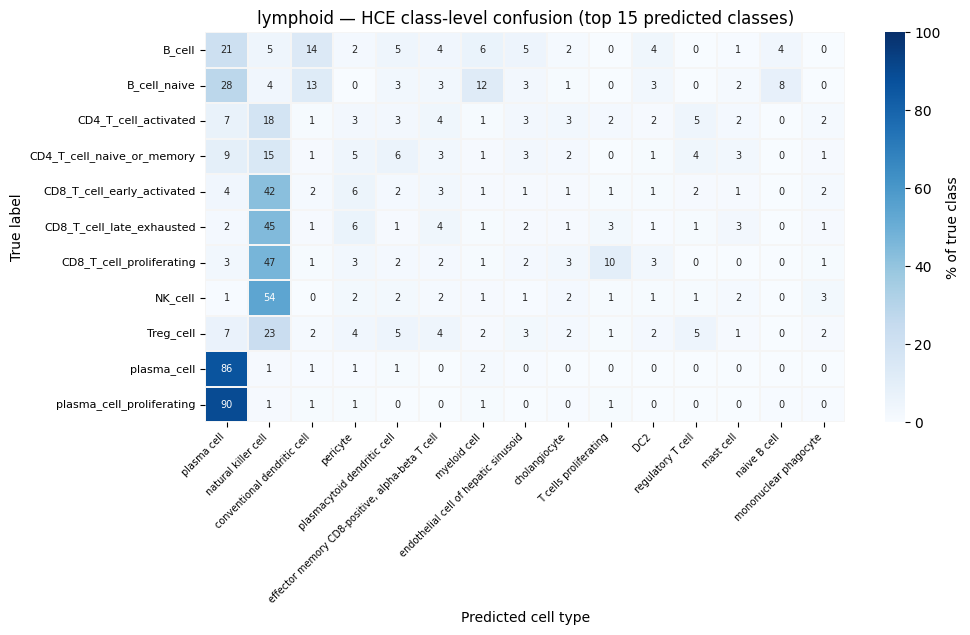

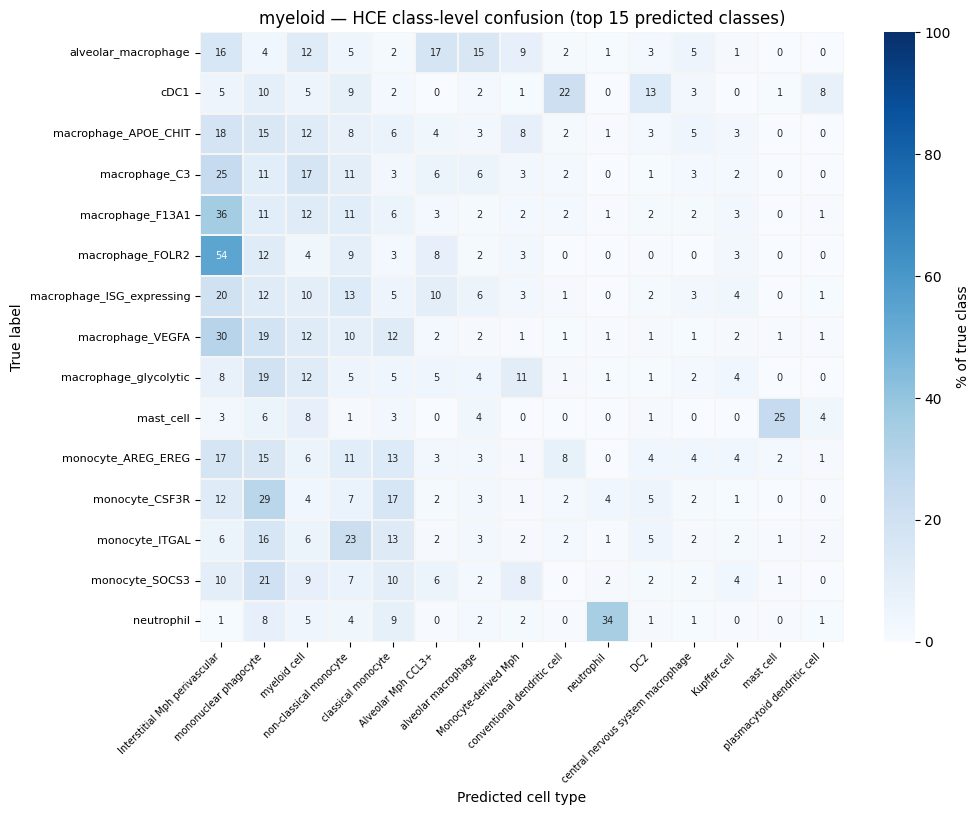

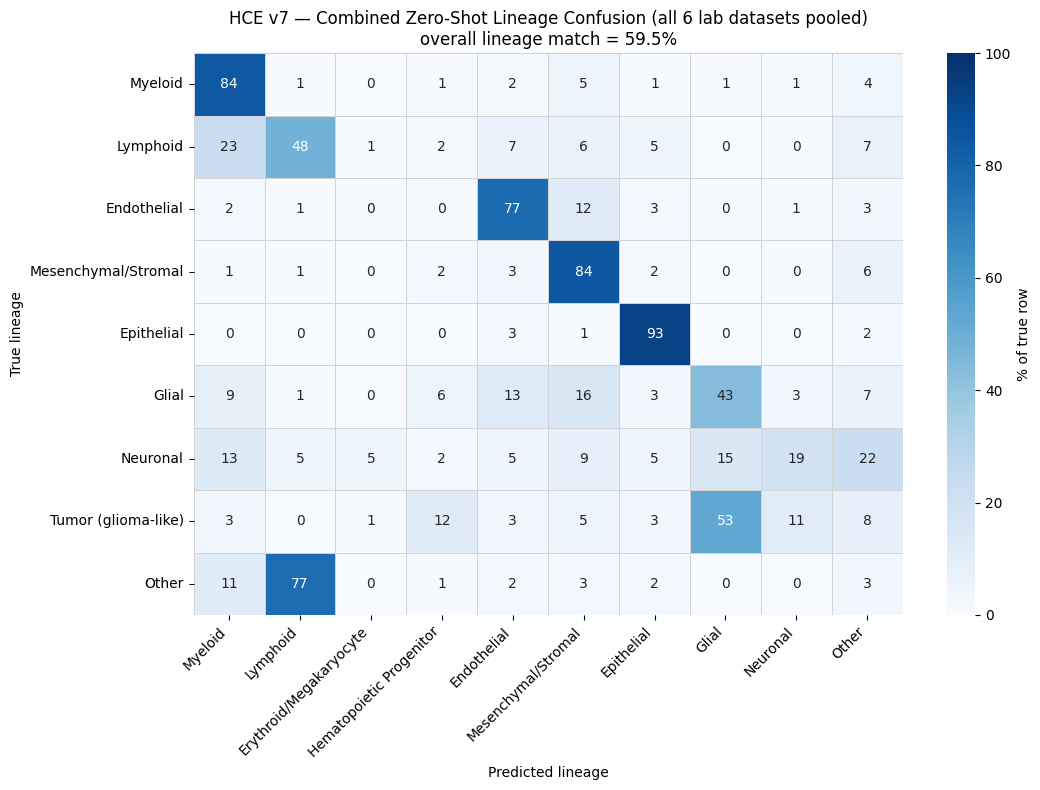


[OK] Confusion matrix visualizations complete


In [23]:
import seaborn as sns

LINEAGE_ORDER = ['Myeloid','Lymphoid','Erythroid/Megakaryocyte','Hematopoietic Progenitor',
                 'Endothelial','Mesenchymal/Stromal','Epithelial','Glial','Neuronal',
                 'Tumor (glioma-like)','Other']

def lineage_confusion(df, order=LINEAGE_ORDER):
    tl = df['true_label'].map(assign_lineage)
    pl = df['pred_leaf'].map(assign_lineage)
    cm = pd.crosstab(tl, pl, normalize='index') * 100
    rows = [o for o in order if o in cm.index]
    cols = [o for o in order if o in cm.columns]
    return cm.reindex(index=rows, columns=cols).fillna(0)


# Per-dataset lineage heatmaps (HCE only)
n_ds = len(LAB_CONFIGS)
fig, axes = plt.subplots(n_ds, 1, figsize=(10, 4.5 * n_ds))
if n_ds == 1: axes = [axes]
fig.suptitle('HCE v7 Zero-Shot Lineage Confusion', fontsize=14, y=1.00)
for ax, lab_cfg in zip(axes, LAB_CONFIGS):
    name = lab_cfg['name']
    df = lab_results_hce[name]
    true_lin = df['true_label'].map(assign_lineage)
    acc      = (df['pred_leaf'].map(assign_lineage) == true_lin).mean() * 100
    cm = lineage_confusion(df)
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=100, cbar=False,
                ax=ax, annot_kws={'size': 9}, linewidths=0.4, linecolor='lightgray')
    ax.set_title(f'{name}  (lineage match = {acc:.1f}%)', fontsize=11)
    ax.set_xlabel('Predicted lineage'); ax.set_ylabel('True lineage')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hce_v7_cm_lineage_per_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()


# Class-level heatmaps per dataset
TOP_N_PREDS = 15
for lab_cfg in LAB_CONFIGS:
    name = lab_cfg['name']
    df = lab_results_hce[name]
    cm = pd.crosstab(df['true_label'], df['pred_leaf'], normalize='index') * 100
    top_cols = cm.sum(axis=0).sort_values(ascending=False).head(TOP_N_PREDS).index.tolist()
    cm = cm.reindex(columns=top_cols, fill_value=0)
    h = max(4, 0.45 * len(cm.index) + 1.5)
    w = max(8, 0.55 * len(cm.columns) + 2.0)
    fig, ax = plt.subplots(figsize=(w, h))
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=100,
                cbar_kws={'label': '% of true class'},
                ax=ax, annot_kws={'size': 7}, linewidths=0.3, linecolor='whitesmoke')
    ax.set_title(f'{name} — HCE class-level confusion (top {len(top_cols)} predicted classes)', fontsize=12)
    ax.set_xlabel('Predicted cell type'); ax.set_ylabel('True label')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    safe = name.replace(' ','_').replace('(','').replace(')','').replace('/','_')
    plt.savefig(os.path.join(OUT_DIR, f'hce_v7_cm_classlevel_{safe}.png'), dpi=150, bbox_inches='tight')
    plt.show()


# Combined pooled lineage matrix
combined_hce = pd.concat(list(lab_results_hce.values()), ignore_index=True)
true_lin_all = combined_hce['true_label'].map(assign_lineage)
acc_all      = (combined_hce['pred_leaf'].map(assign_lineage) == true_lin_all).mean() * 100

fig, ax = plt.subplots(figsize=(11, 8))
cm = lineage_confusion(combined_hce)
sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=100,
            cbar_kws={'label': '% of true row'},
            ax=ax, annot_kws={'size': 10}, linewidths=0.5, linecolor='lightgray')
ax.set_title(f'HCE v7 — Combined Zero-Shot Lineage Confusion (all {len(LAB_CONFIGS)} lab datasets pooled)\noverall lineage match = {acc_all:.1f}%', fontsize=12)
ax.set_xlabel('Predicted lineage'); ax.set_ylabel('True lineage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hce_v7_cm_lineage_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n[OK] Confusion matrix visualizations complete')

## 16. Final Summary

In [24]:
print('=' * 80)
print('  HCE v10 — FINAL SUMMARY')
print('=' * 80)

print('\nTRAINING')
print(f'  Best validation accuracy : {hce_best_acc:.4f}')

print('\nTEST SET (in-distribution)')
m = results_hce['COMBINED']
print(f'  accuracy            : {m["accuracy"]:.4f}')
print(f'  macro_recall        : {m["macro_recall"]:.4f}')
print(f'  macro_f1            : {m["macro_f1"]:.4f}')
print(f'  zero_recall_count   : {m["zero_recall_count"]}')
print(f'  recall_50_pct       : {m["recall_50_pct"]:.4f}')
print(f'  recall_80_pct       : {m["recall_80_pct"]:.4f}')

print('\nPER-ORGAN MACRO RECALL (test set)')
print(f'  {"Organ":<20}{"HCE":>10}')
print('  ' + '-' * 30)
for cfg in ORGAN_CONFIGS:
    if cfg['name'] in results_hce:
        r = results_hce[cfg['name']]['macro_recall']
        print(f'  {cfg["name"]:<20}{r:>10.4f}')

print('\nZERO-SHOT LINEAGE MATCH (per lab dataset)')
print(f'  {"Dataset":<26}{"HCE":>10}')
print('  ' + '-' * 36)
for lab_name in lab_results_hce.keys():
    df = lab_results_hce[lab_name]
    rate = (df['pred_leaf'].map(assign_lineage) == df['true_label'].map(assign_lineage)).mean()
    print(f'  {lab_name:<26}{rate*100:>9.1f}%')
print(f'  {"POOLED":<26}{acc_all:>9.1f}%')

print('\n  Outputs saved to:', OUT_DIR)

  HCE v10 — FINAL SUMMARY

TRAINING
  Best validation accuracy : 0.7490

TEST SET (in-distribution)
  accuracy            : 0.7495
  macro_recall        : 0.7703
  macro_f1            : 0.7661
  zero_recall_count   : 0
  recall_50_pct       : 0.9204
  recall_80_pct       : 0.5265

PER-ORGAN MACRO RECALL (test set)
  Organ                      HCE
  ------------------------------
  lung                    0.8373
  brain_glia              0.9436
  brain_neurons           0.9604
  liver                   0.6760
  lymph_node              0.6190
  bone_marrow             0.7070

ZERO-SHOT LINEAGE MATCH (per lab dataset)
  Dataset                          HCE
  ------------------------------------
  All_cells (glioma)             60.9%
  Brain_normal                   29.7%
  Liver_normal                   81.7%
  Lymph_node_normal              79.1%
  lymphoid                       32.2%
  myeloid                        86.1%
  POOLED                         59.5%

  Outputs saved to: multi

## 17. HCE v10 vs CE v10 — Test Set Comparison


In [25]:
# v10 comparison: HCE vs CE on the v10 test set (mirrors v6 hce_vs_ce_comparison.csv schema)
import os, pandas as pd

metric_cols = ['accuracy', 'macro_recall', 'macro_f1', 'zero_recall_count',
               'recall_50_pct', 'recall_80_pct']
rows = []
for organ_name in [c['name'] for c in ORGAN_CONFIGS] + ['COMBINED']:
    h = results_hce.get(organ_name); c = results_ce.get(organ_name)
    if h is None or c is None: continue
    row = {'organ': organ_name}
    for col in metric_cols:
        row[f'HCE_{col}']   = h[col]
        row[f'CE_{col}']    = c[col]
        row[f'delta_{col}'] = h[col] - c[col]
    rows.append(row)
hce_vs_ce_df = pd.DataFrame(rows).set_index('organ')
hce_vs_ce_df.to_csv(os.path.join(OUT_DIR, 'hce_vs_ce_v10_comparison.csv'))

print('=' * 80)
print('  HCE v10 vs CE v10 — TEST SET (per organ)')
print('=' * 80)
print(f'\n  {"Organ":<22} {"Metric":<20} {"CE":>10} {"HCE":>10} {"Delta":>10}')
print('  ' + '-' * 76)
for organ_name, row in hce_vs_ce_df.iterrows():
    first = True
    for col in metric_cols:
        ce, hce, delta = row[f'CE_{col}'], row[f'HCE_{col}'], row[f'delta_{col}']
        fc = f'{ce:.0f}' if col=='zero_recall_count' else f'{ce:.4f}'
        fh = f'{hce:.0f}' if col=='zero_recall_count' else f'{hce:.4f}'
        fd = f'{delta:+.0f}' if col=='zero_recall_count' else f'{delta:+.4f}'
        is_lower_better = col == 'zero_recall_count'
        wins = (delta < 0) if is_lower_better else (delta > 0)
        flag = ' ← HCE' if wins and abs(delta) > (1 if is_lower_better else 0.005) else ''
        label = organ_name if first else ''
        print(f'  {label:<22} {col:<20} {fc:>10} {fh:>10} {fd:>10}{flag}')
        first = False
    print()

print(f'[OK] Saved to {OUT_DIR}/hce_vs_ce_v10_comparison.csv')

# ── Historical context: v6/v7/v8/v9/v10 HCE lineage-match snapshot ───────────
print('\n' + '=' * 80)
print('  HCE lineage-match across versions (zero-shot pooled)')
print('=' * 80)
historical = {
    'v6 (HCE only)':  None,
    'v7':             61.0,
    'v8':             60.6,
    'v9 Stage 1':     56.5,
}
# v10 computed below in the zero-shot comparison cell
print(f'  {"version":<18} {"pooled lineage-match"}')
for k,v in historical.items():
    print(f'  {k:<18} {"n/a" if v is None else f"{v:.1f}%"}')
print('  v10                see next cell')


  HCE v10 vs CE v10 — TEST SET (per organ)

  Organ                  Metric                       CE        HCE      Delta
  ----------------------------------------------------------------------------
  lung                   accuracy                 0.8049     0.8373    +0.0324 ← HCE
                         macro_recall             0.8049     0.8373    +0.0324 ← HCE
                         macro_f1                 0.8192     0.8488    +0.0296 ← HCE
                         zero_recall_count             0          0         +0
                         recall_50_pct            1.0000     1.0000    +0.0000
                         recall_80_pct            0.6441     0.7119    +0.0678 ← HCE

  brain_glia             accuracy                 0.9464     0.9436    -0.0028
                         macro_recall             0.9464     0.9436    -0.0028
                         macro_f1                 0.9486     0.9474    -0.0013
                         zero_recall_count             0      

## 17b. HCE v10 vs CE v10 — Zero-shot lineage-match


In [26]:
# v10 zero-shot HCE vs CE comparison (uses fixed assign_lineage with Mph/EC keywords)
print('=' * 80)
print('  HCE v10 vs CE v10 — ZERO-SHOT LINEAGE-MATCH')
print('=' * 80)

rows = []
hce_pool_leaf, hce_pool_lin, ce_pool_leaf, total_n = 0, 0, 0, 0
for lab_name in [c['name'] for c in LAB_CONFIGS]:
    df_h = lab_results_hce.get(lab_name); df_c = lab_results_ce.get(lab_name)
    if df_h is None or df_c is None: continue
    n = len(df_h)
    h_leaf = sum(assign_lineage(t) == assign_lineage(p) for t,p in zip(df_h['true_label'], df_h['pred_leaf']))
    h_lin  = sum(assign_lineage(t) == assign_lineage(p) for t,p in zip(df_h['true_label'], df_h['pred_lineage']))
    c_leaf = sum(assign_lineage(t) == assign_lineage(p) for t,p in zip(df_c['true_label'], df_c['pred_leaf']))
    rows.append({
        'dataset': lab_name, 'n': n,
        'HCE_leaf_pct':    h_leaf/n*100,
        'HCE_lineage_pct': h_lin/n*100,
        'CE_leaf_pct':     c_leaf/n*100,
        'delta_HCElin_CEleaf': (h_lin - c_leaf)/n*100,
    })
    hce_pool_leaf += h_leaf; hce_pool_lin += h_lin; ce_pool_leaf += c_leaf; total_n += n

zs_df = pd.DataFrame(rows)
zs_df.to_csv(os.path.join(OUT_DIR, 'hce_vs_ce_v10_zeroshot.csv'), index=False)

print(f'\n  {"Dataset":<22} {"n":>6} {"CE leaf":>10} {"HCE leaf":>10} {"HCE lineage":>14} {"Δ HCElin-CElf":>16}')
print('  ' + '-' * 84)
for r in rows:
    print(f'  {r["dataset"]:<22} {r["n"]:>6} {r["CE_leaf_pct"]:>9.1f}% {r["HCE_leaf_pct"]:>9.1f}% {r["HCE_lineage_pct"]:>13.1f}% {r["delta_HCElin_CEleaf"]:>+14.1f}pt')

if total_n:
    print(f'\n  {"POOLED":<22} {total_n:>6} {ce_pool_leaf/total_n*100:>9.1f}% {hce_pool_leaf/total_n*100:>9.1f}% {hce_pool_lin/total_n*100:>13.1f}% {(hce_pool_lin-ce_pool_leaf)/total_n*100:>+14.1f}pt')

print(f'\n[OK] Saved to {OUT_DIR}/hce_vs_ce_v10_zeroshot.csv')
print(f'\n  Acceptance: pooled HCE lineage ≥ 66% (v7: 61.0; v8: 60.6; v9 Stage 1: 56.5)')


  HCE v10 vs CE v10 — ZERO-SHOT LINEAGE-MATCH

  Dataset                     n    CE leaf   HCE leaf    HCE lineage    Δ HCElin-CElf
  ------------------------------------------------------------------------------------
  All_cells (glioma)       2609      65.1%      60.9%          61.6%           -3.5pt
  Brain_normal             2773      47.1%      29.7%          26.8%          -20.3pt
  Liver_normal             2806      78.4%      81.7%          79.9%           +1.5pt
  Lymph_node_normal        2357      81.5%      79.1%          78.9%           -2.6pt
  lymphoid                 7173      38.2%      32.2%          39.5%           +1.3pt
  myeloid                  6218      81.5%      86.1%          80.7%           -0.9pt

  POOLED                  23936      62.4%      59.5%          59.7%           -2.7pt

[OK] Saved to multi_tissue_v10_results/hce_vs_ce_v10_zeroshot.csv

  Acceptance: pooled HCE lineage ≥ 66% (v7: 61.0; v8: 60.6; v9 Stage 1: 56.5)


## 18. Biology Spot-Checks (v8 acceptance criteria)


In [27]:
# v10 biology spot-checks — run for BOTH HCE and CE
SPOT_CHECKS = [
    ('lymphoid',          'CD4_T_cell',     ['CD4'],                           'lineage'),
    ('lymphoid',          'Treg_cell',      ['CD4', 'regulatory'],             'lineage'),
    ('lymphoid',          'CD8_T_cell',     ['CD8'],                           'leaf'),
    ('myeloid',           'monocyte_',      ['monocyte'],                      'leaf'),
    ('Brain_normal',      'oligodendrocyte', ['oligodendrocyte'],              'leaf'),
    ('Liver_normal',      'hepatocyte',     ['hepatocyte'],                    'leaf'),
    ('Liver_normal',      'cholangiocyte',  ['cholangiocyte'],                 'leaf'),
    ('Lymph_node_normal', 'LN_stroma_cell', ['fibroblast', 'stroma'],          'lineage'),
    ('Brain_normal',      'GABAergic',      ['interneuron', 'inhibitory neuron','GABA'], 'lineage'),
]

def _eval_spot_checks(lab_results, model_label, has_lineage):
    """has_lineage=True for HCE (pred_lineage column exists), False for CE."""
    print(f'\n  --- Spot checks for {model_label} ---')
    print(f'  {"Dataset":<22} {"True label":<28} {"Top pred":<45} {"Axis":<8} {"PASS?":<6}')
    print('  ' + '-' * 110)
    n_pass, n_total = 0, 0
    for ds_name, true_sub, allowed_subs, axis in SPOT_CHECKS:
        df = lab_results.get(ds_name)
        if df is None:
            print(f'  {ds_name:<22}  (dataset not found)')
            continue
        if axis == 'lineage' and has_lineage:
            pred_col = 'pred_lineage'
        else:
            pred_col = 'pred_leaf'
        sub = df[df['true_label'].str.contains(true_sub, case=False, na=False, regex=False)]
        if len(sub) == 0:
            print(f'  {ds_name:<22} {true_sub:<28}  (no matching cells)')
            continue
        top = sub[pred_col].value_counts()
        top_pred = top.index[0]
        passed = any(a.lower() in top_pred.lower() for a in allowed_subs)
        n_total += 1; n_pass += int(passed)
        axis_used = axis if (axis=='leaf' or has_lineage) else 'leaf*'
        print(f'  {ds_name:<22} {true_sub:<28} {top_pred:<45} {axis_used:<8} {"PASS" if passed else "FAIL":<6}')
    print(f'\n  {model_label} spot checks: {n_pass}/{n_total}')
    return n_pass, n_total

hce_pass, hce_total = _eval_spot_checks(lab_results_hce, 'HCE v10', has_lineage=True)
ce_pass,  ce_total  = _eval_spot_checks(lab_results_ce,  'CE  v10', has_lineage=False)
print(f'\n  Final: HCE {hce_pass}/{hce_total}   CE {ce_pass}/{ce_total}')
print('  (HCE acceptance target: ≥ 6 of 9)')



  --- Spot checks for HCE v10 ---
  Dataset                True label                   Top pred                                      Axis     PASS? 
  --------------------------------------------------------------------------------------------------------------
  lymphoid               CD4_T_cell                   leukocyte                                     lineage  FAIL  
  lymphoid               Treg_cell                    leukocyte                                     lineage  FAIL  
  lymphoid               CD8_T_cell                   natural killer cell                           leaf     FAIL  
  myeloid                monocyte_                    mononuclear phagocyte                         leaf     FAIL  
  Brain_normal           oligodendrocyte              committed oligodendrocyte precursor           leaf     PASS  
  Liver_normal           hepatocyte                   periportal region hepatocyte                  leaf     PASS  
  Liver_normal           cholangiocyte  